In [126]:
d.advert <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/advert.dat",
header = TRUE)
ts.advert <- ts(log(d.advert[, "ADVERT"]), start = 1907)
ts.sales <- ts(log(d.advert[, "SALES"]), start = 1907)


In [127]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

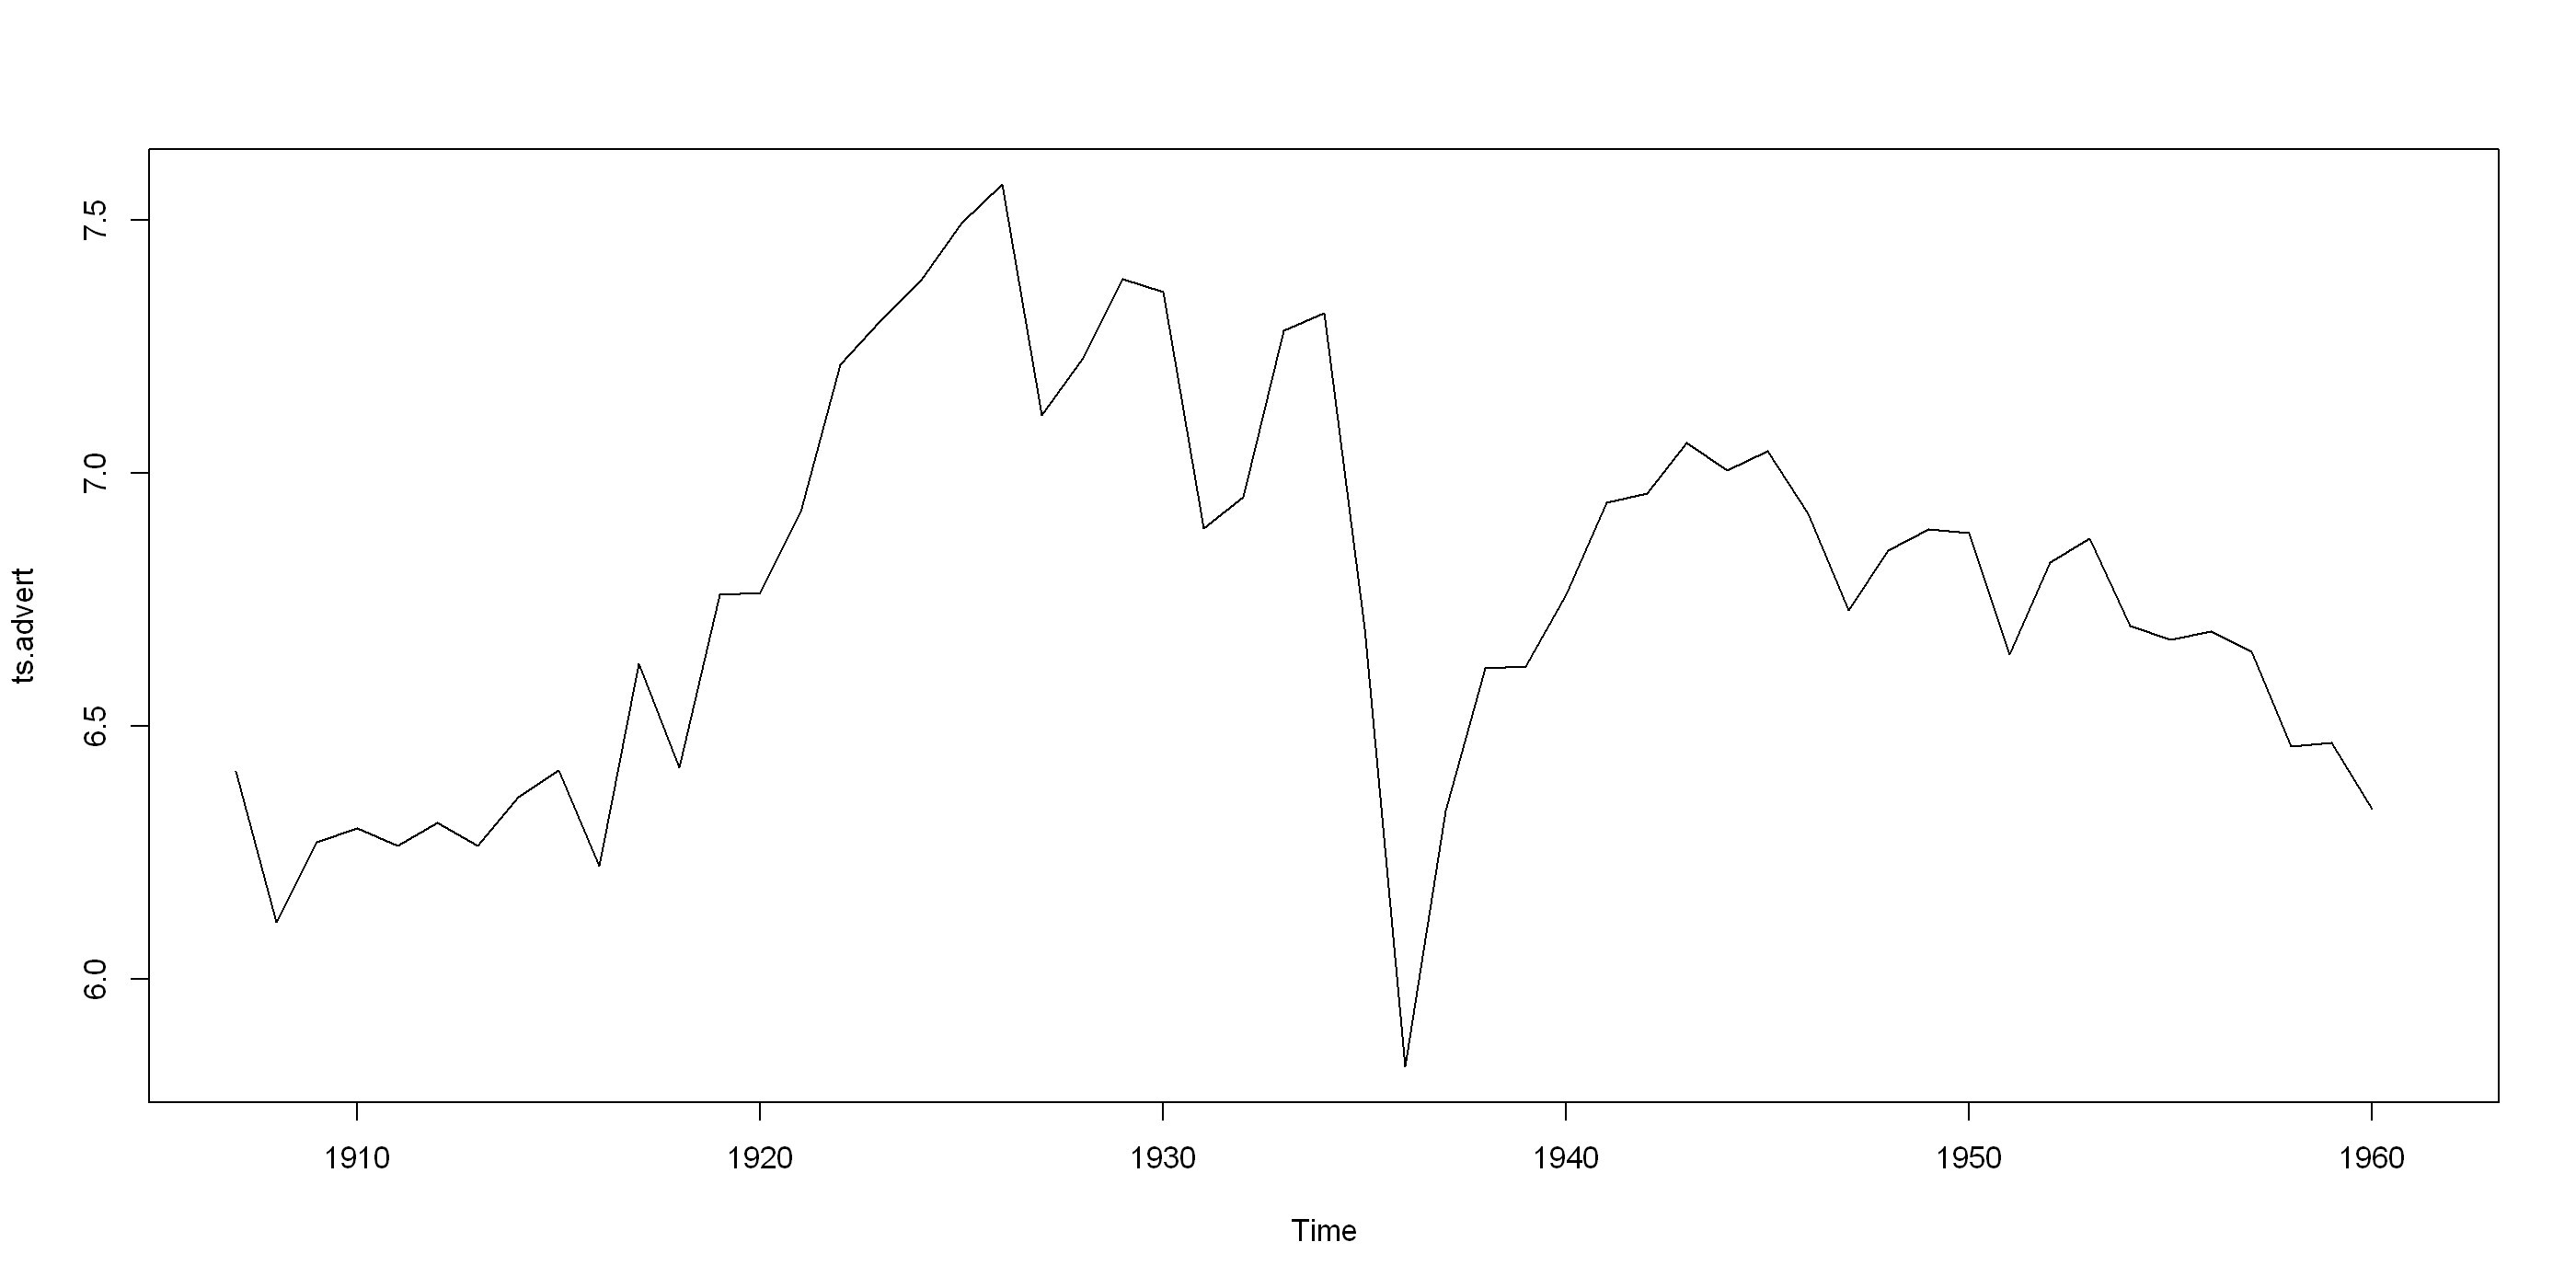

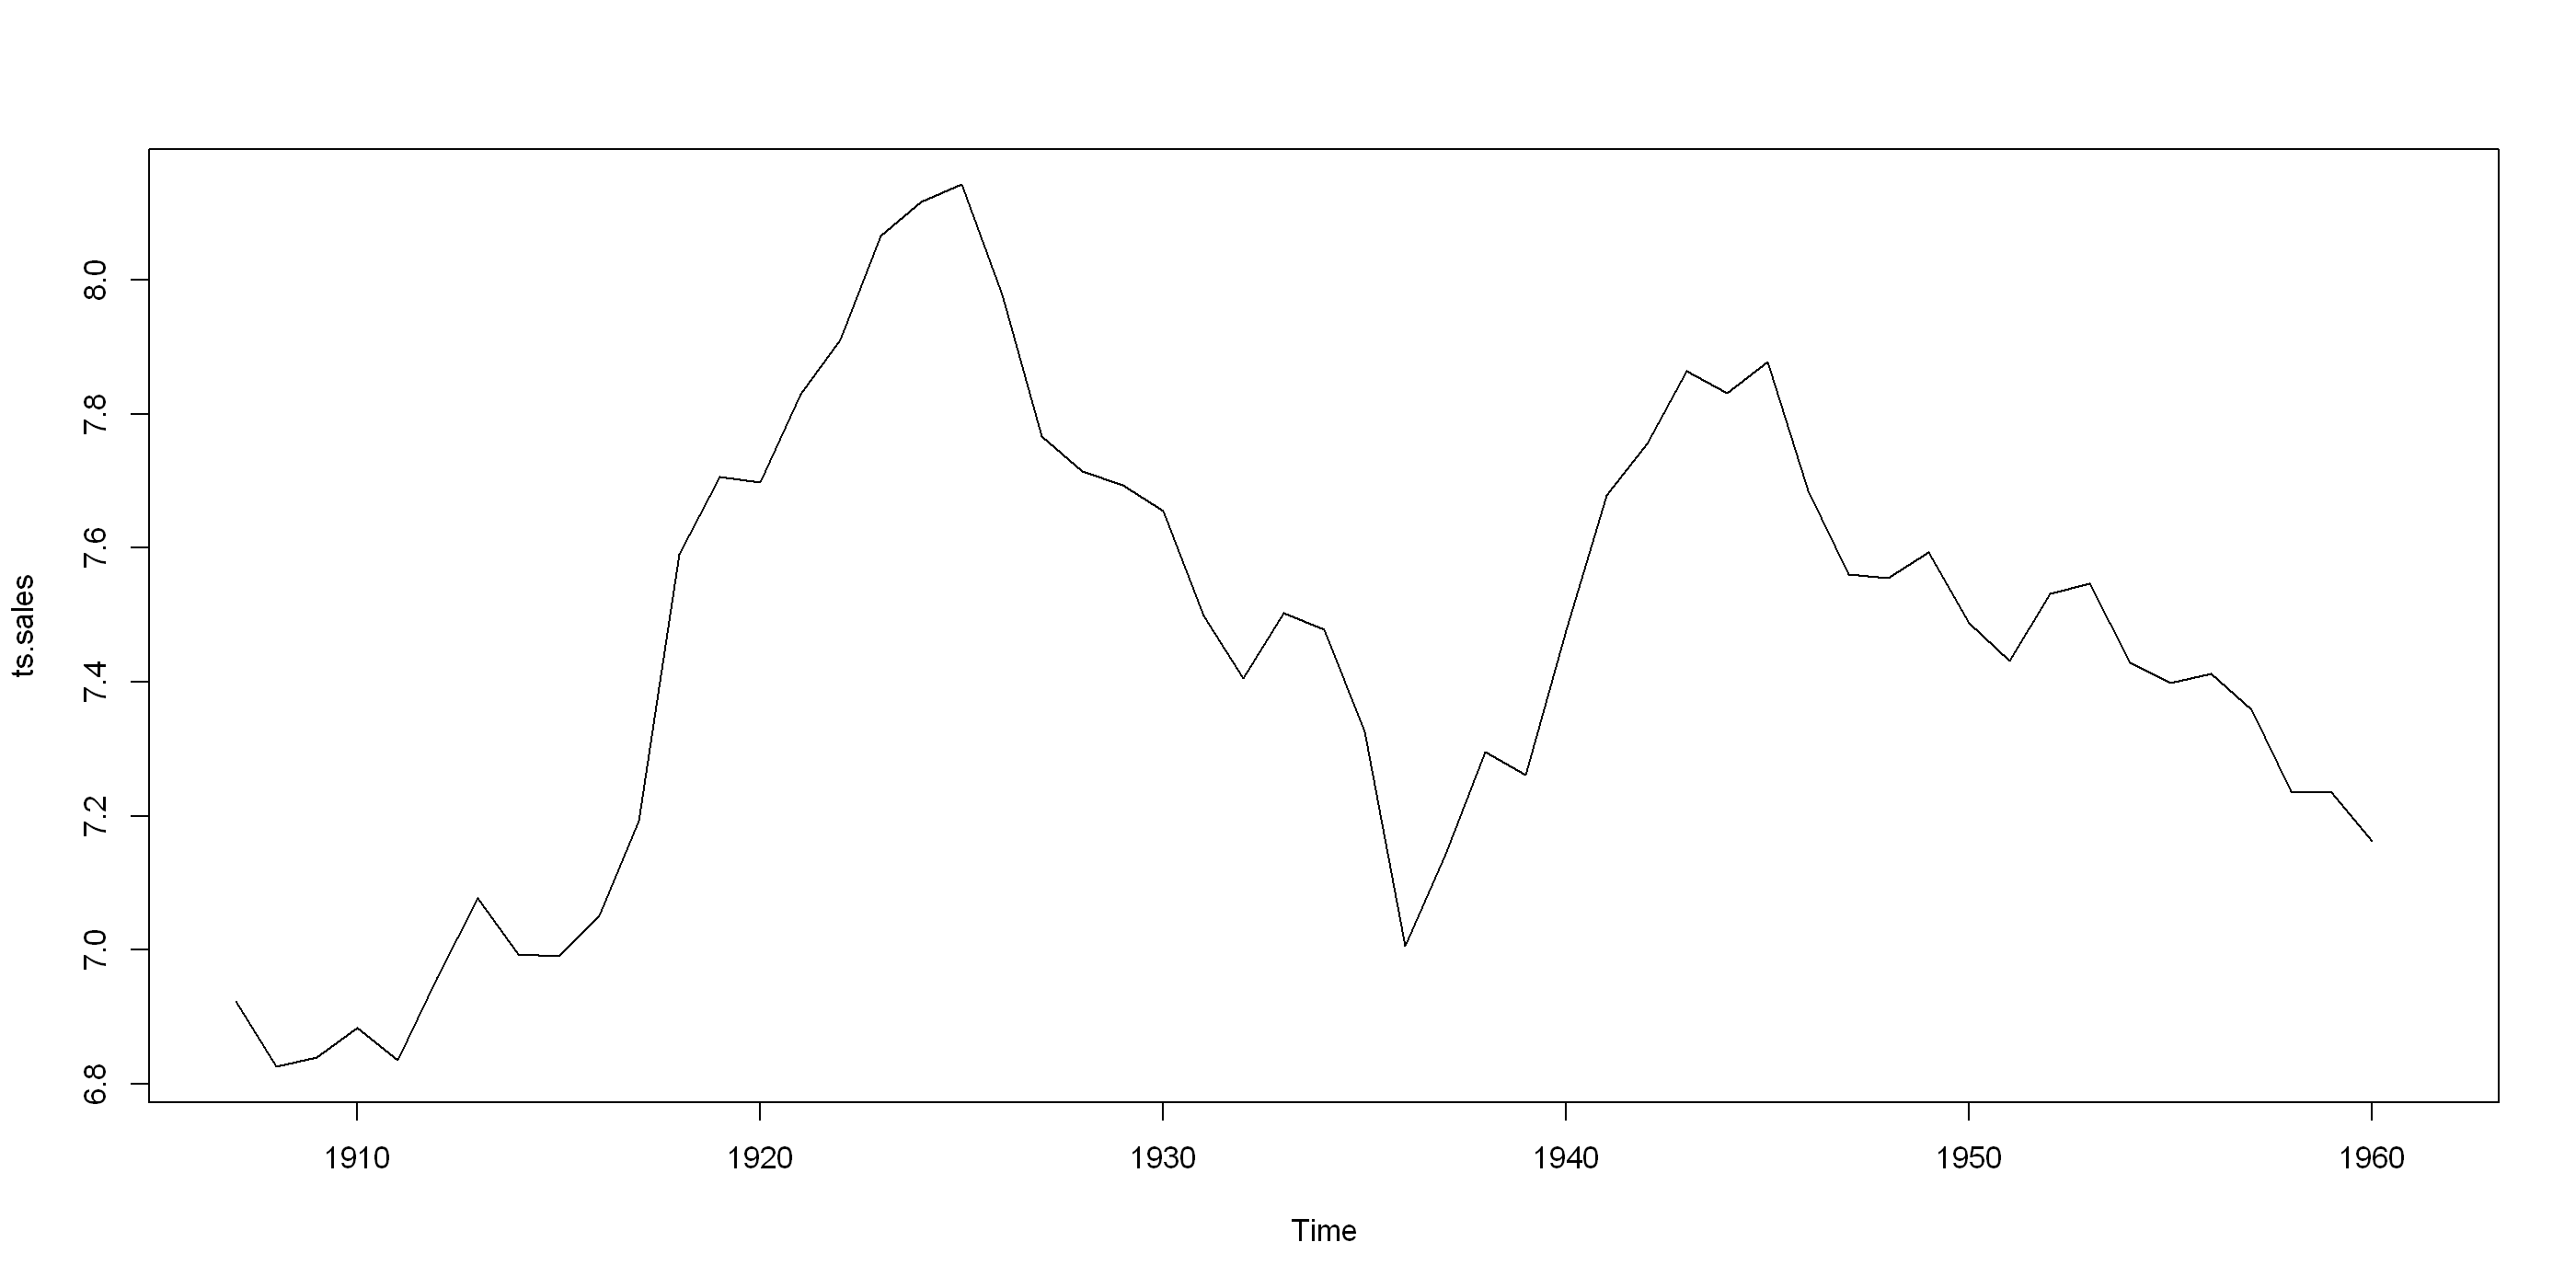

In [128]:
plot(ts.advert)
plot(ts.sales)

In [129]:
ts.adv.d1 <- diff(ts.advert)
ts.sal.d1 <- diff(ts.sales)

In [130]:
n <- length(ts.adv.d1)

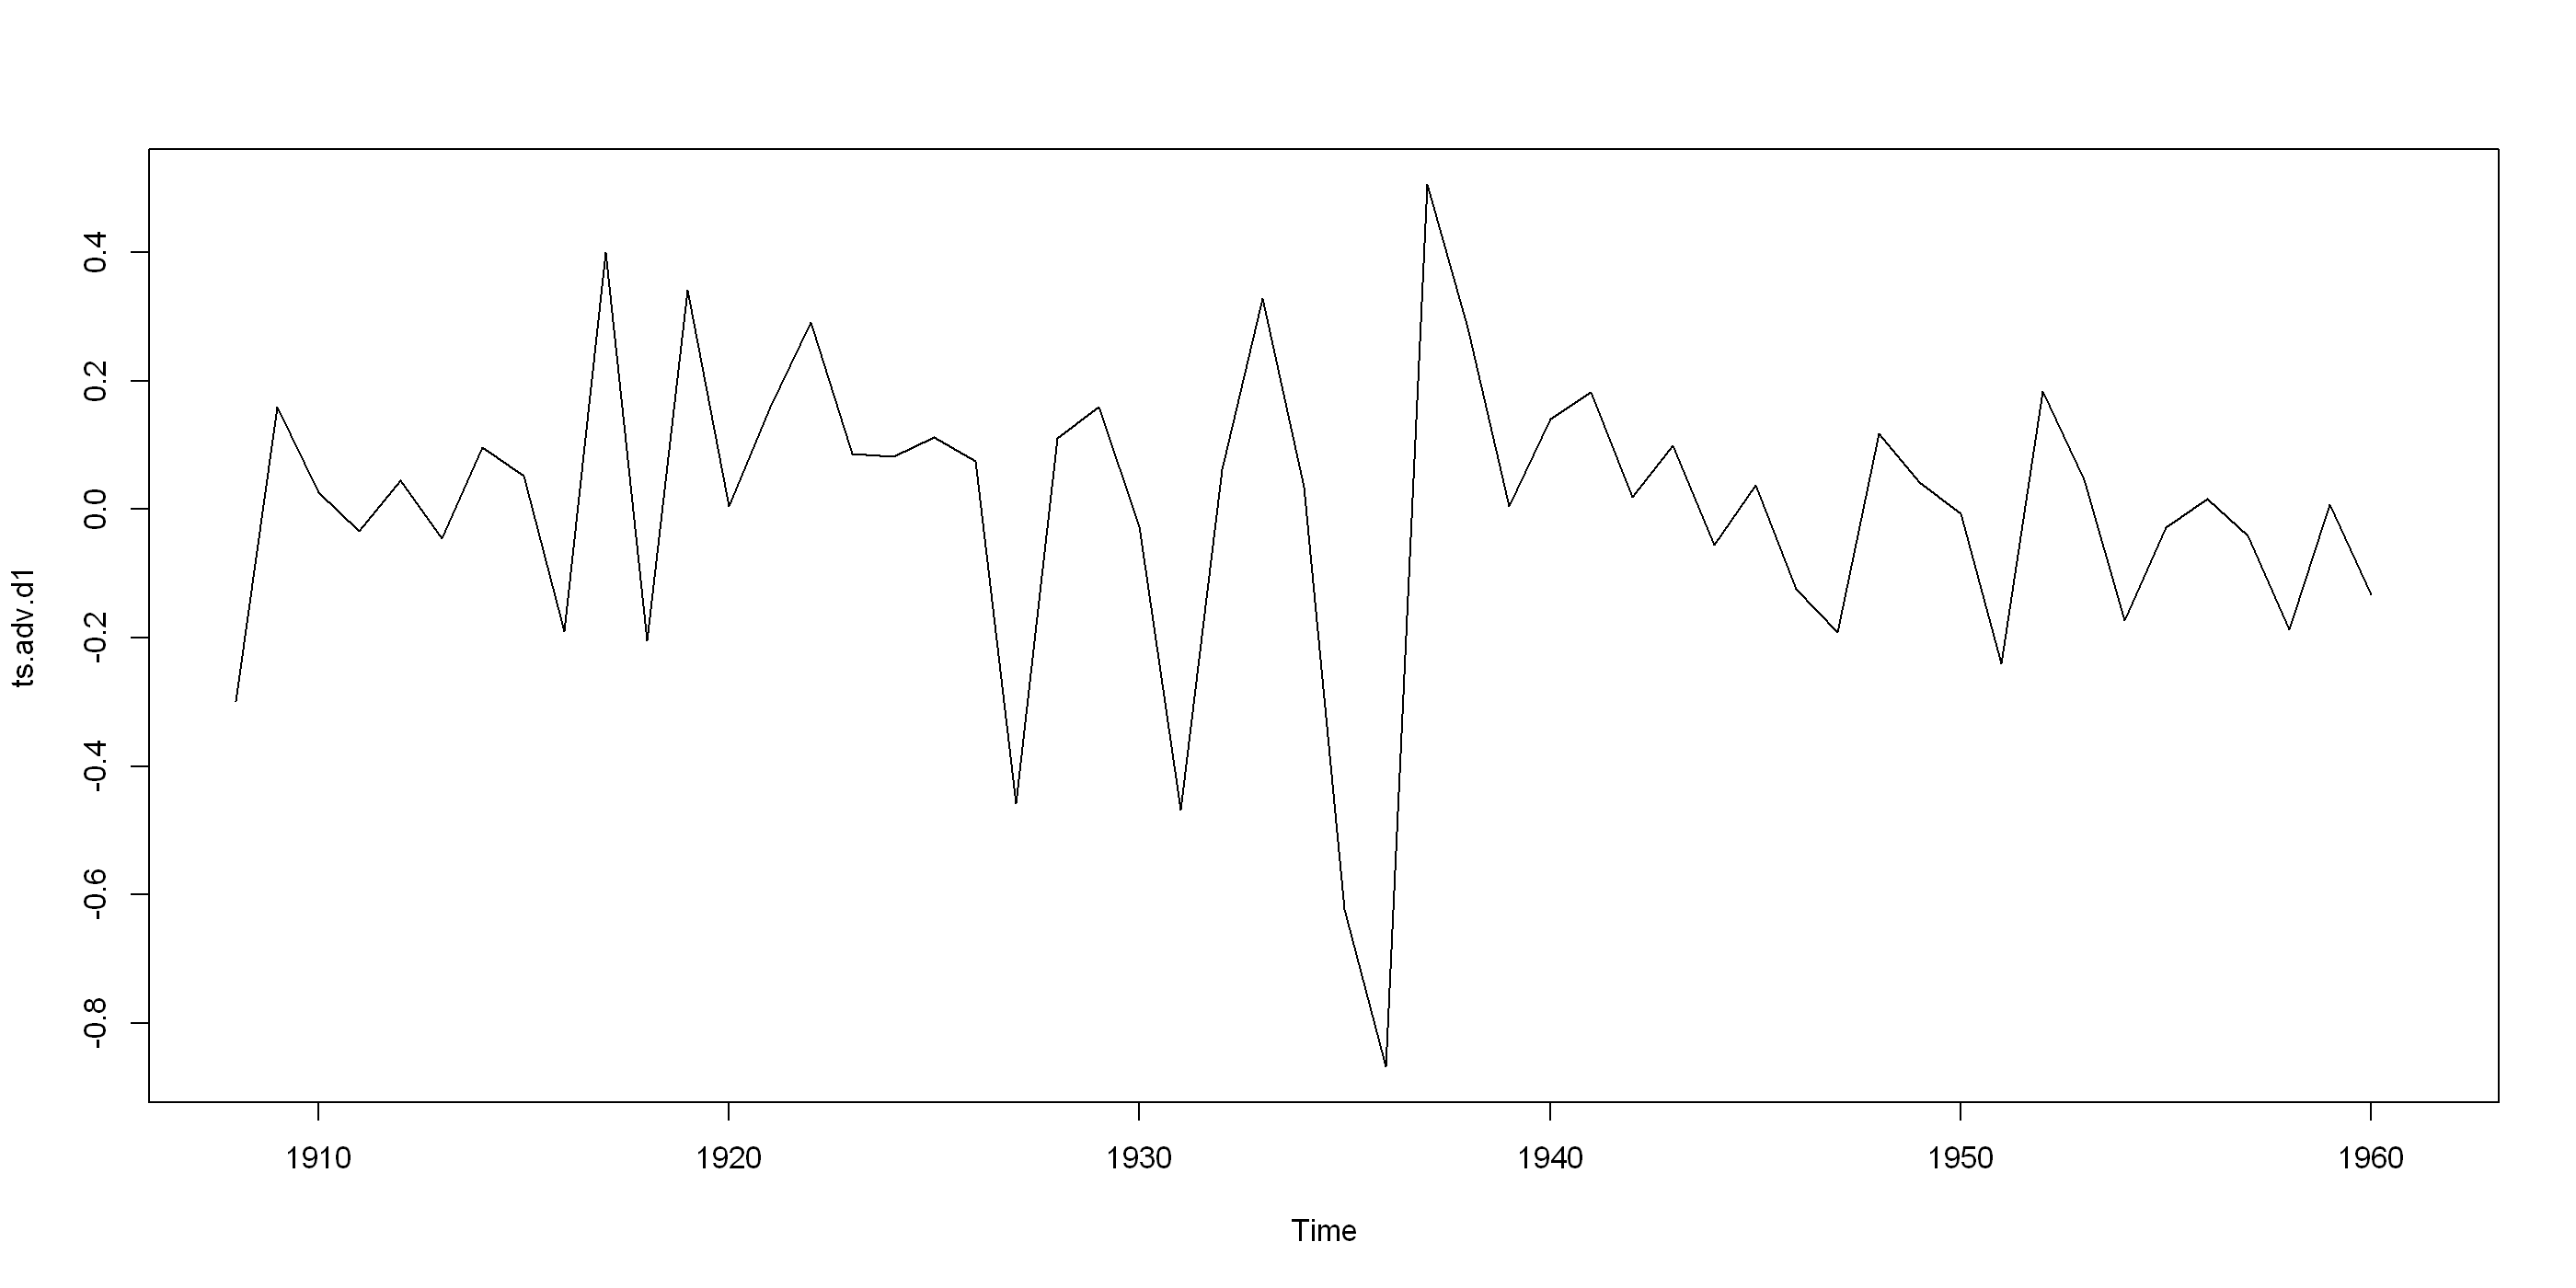

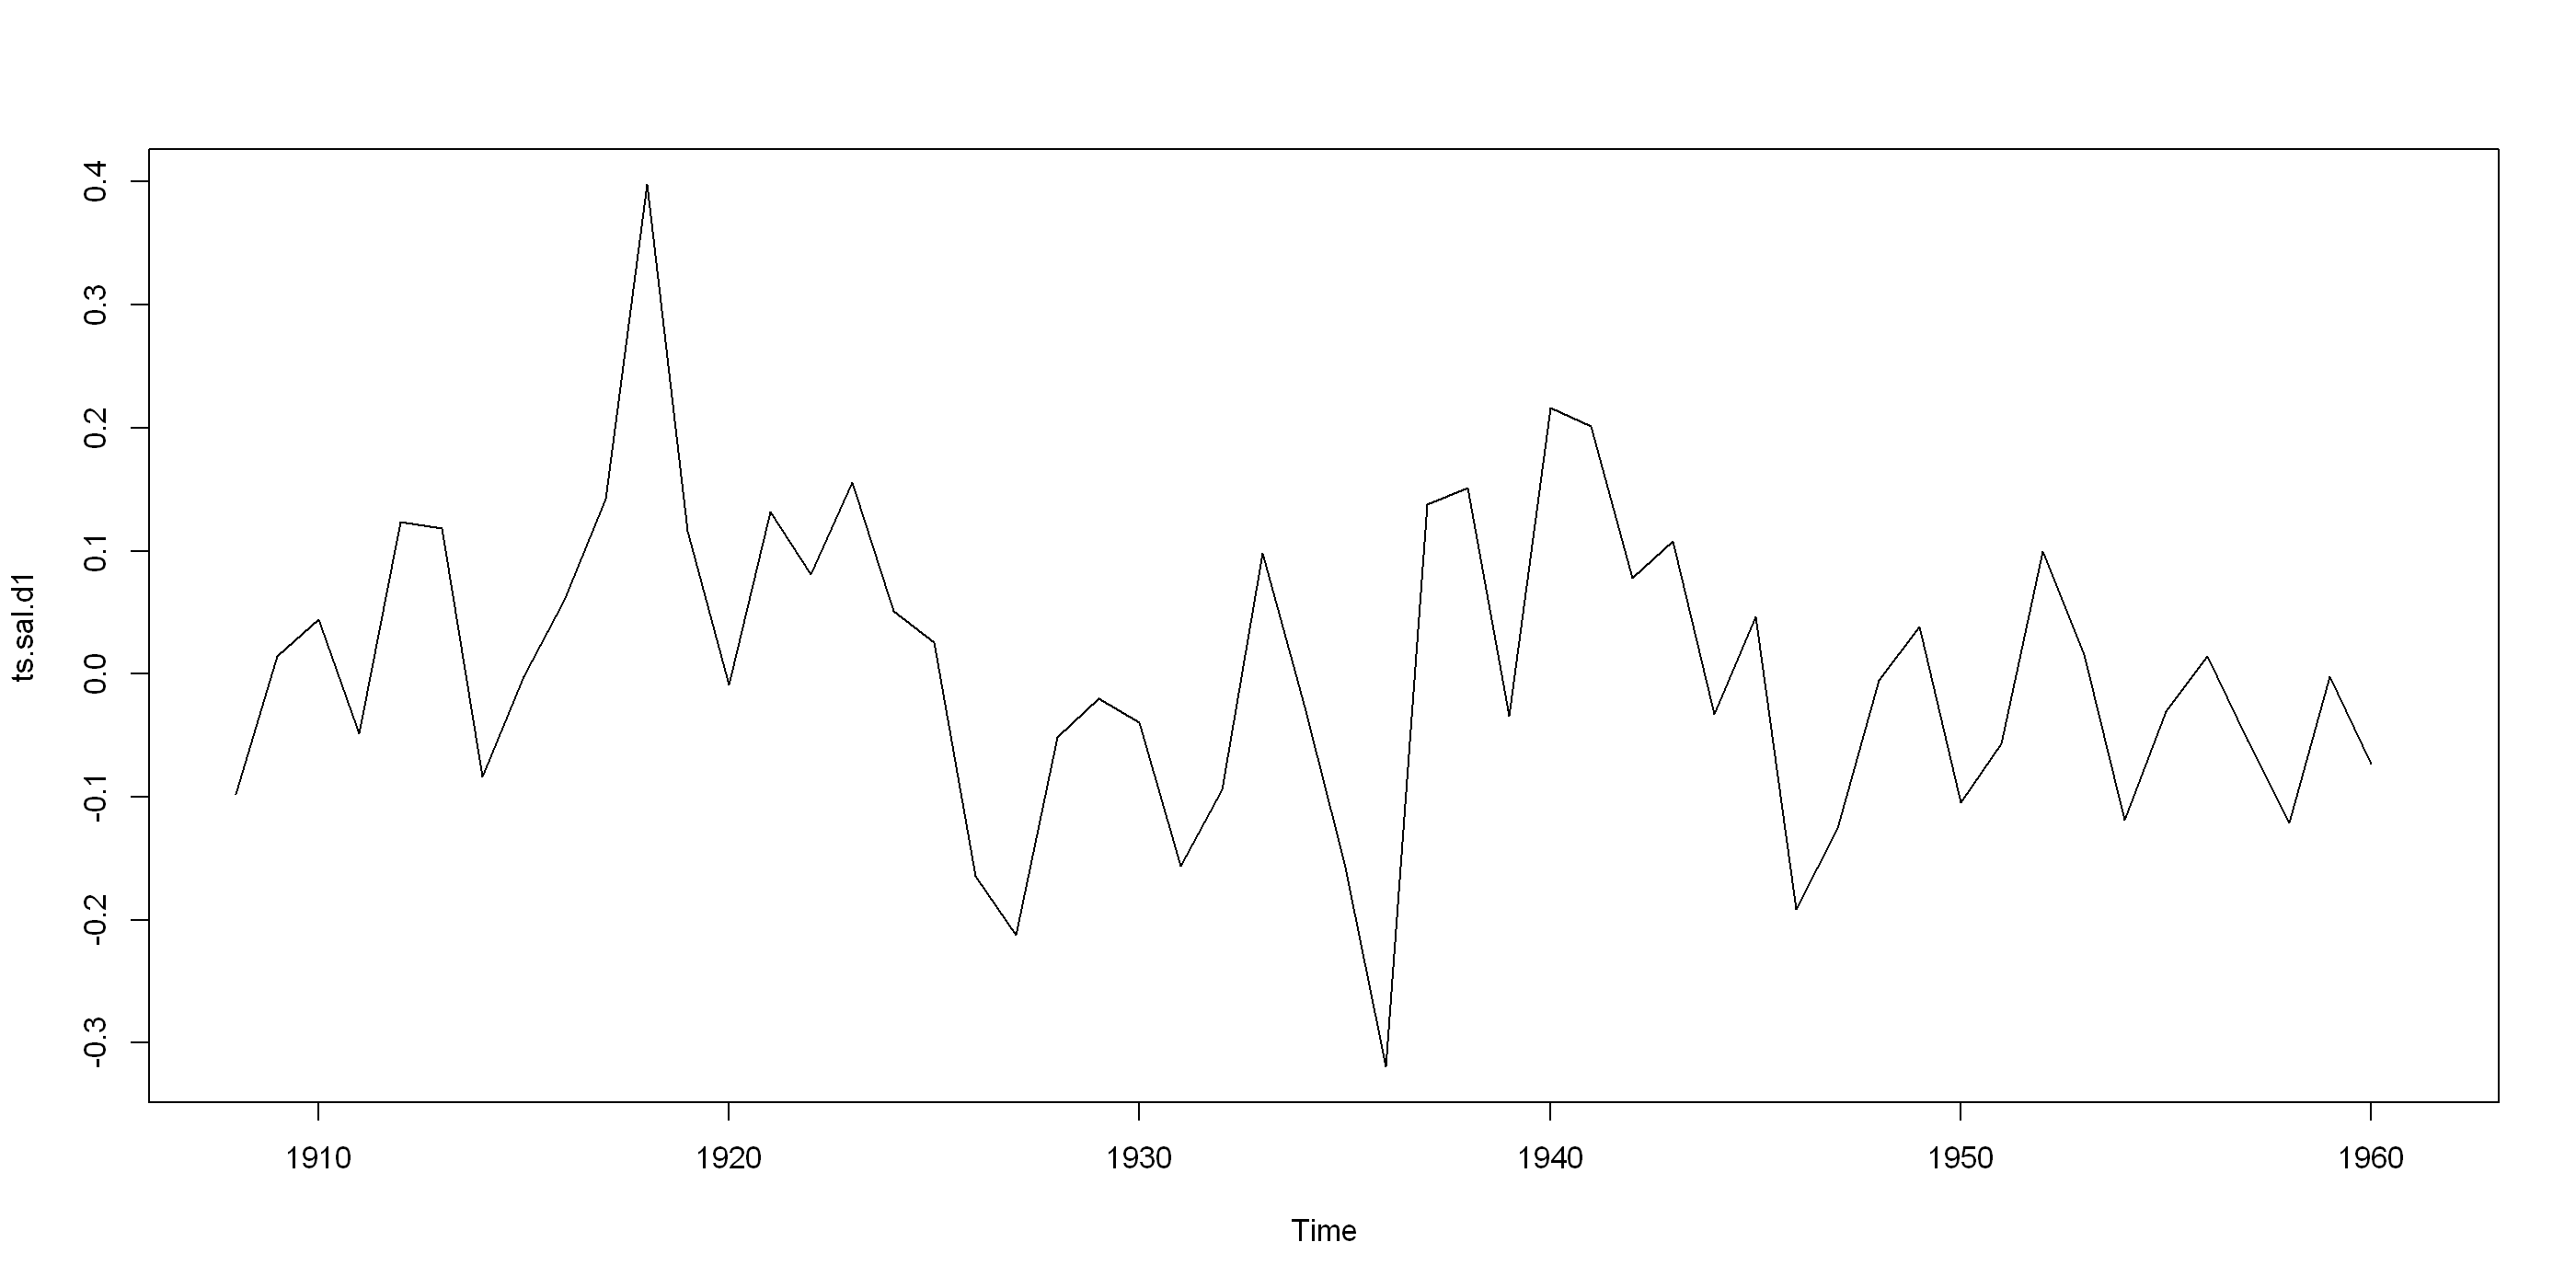

In [131]:
plot(ts.adv.d1)
plot(ts.sal.d1)

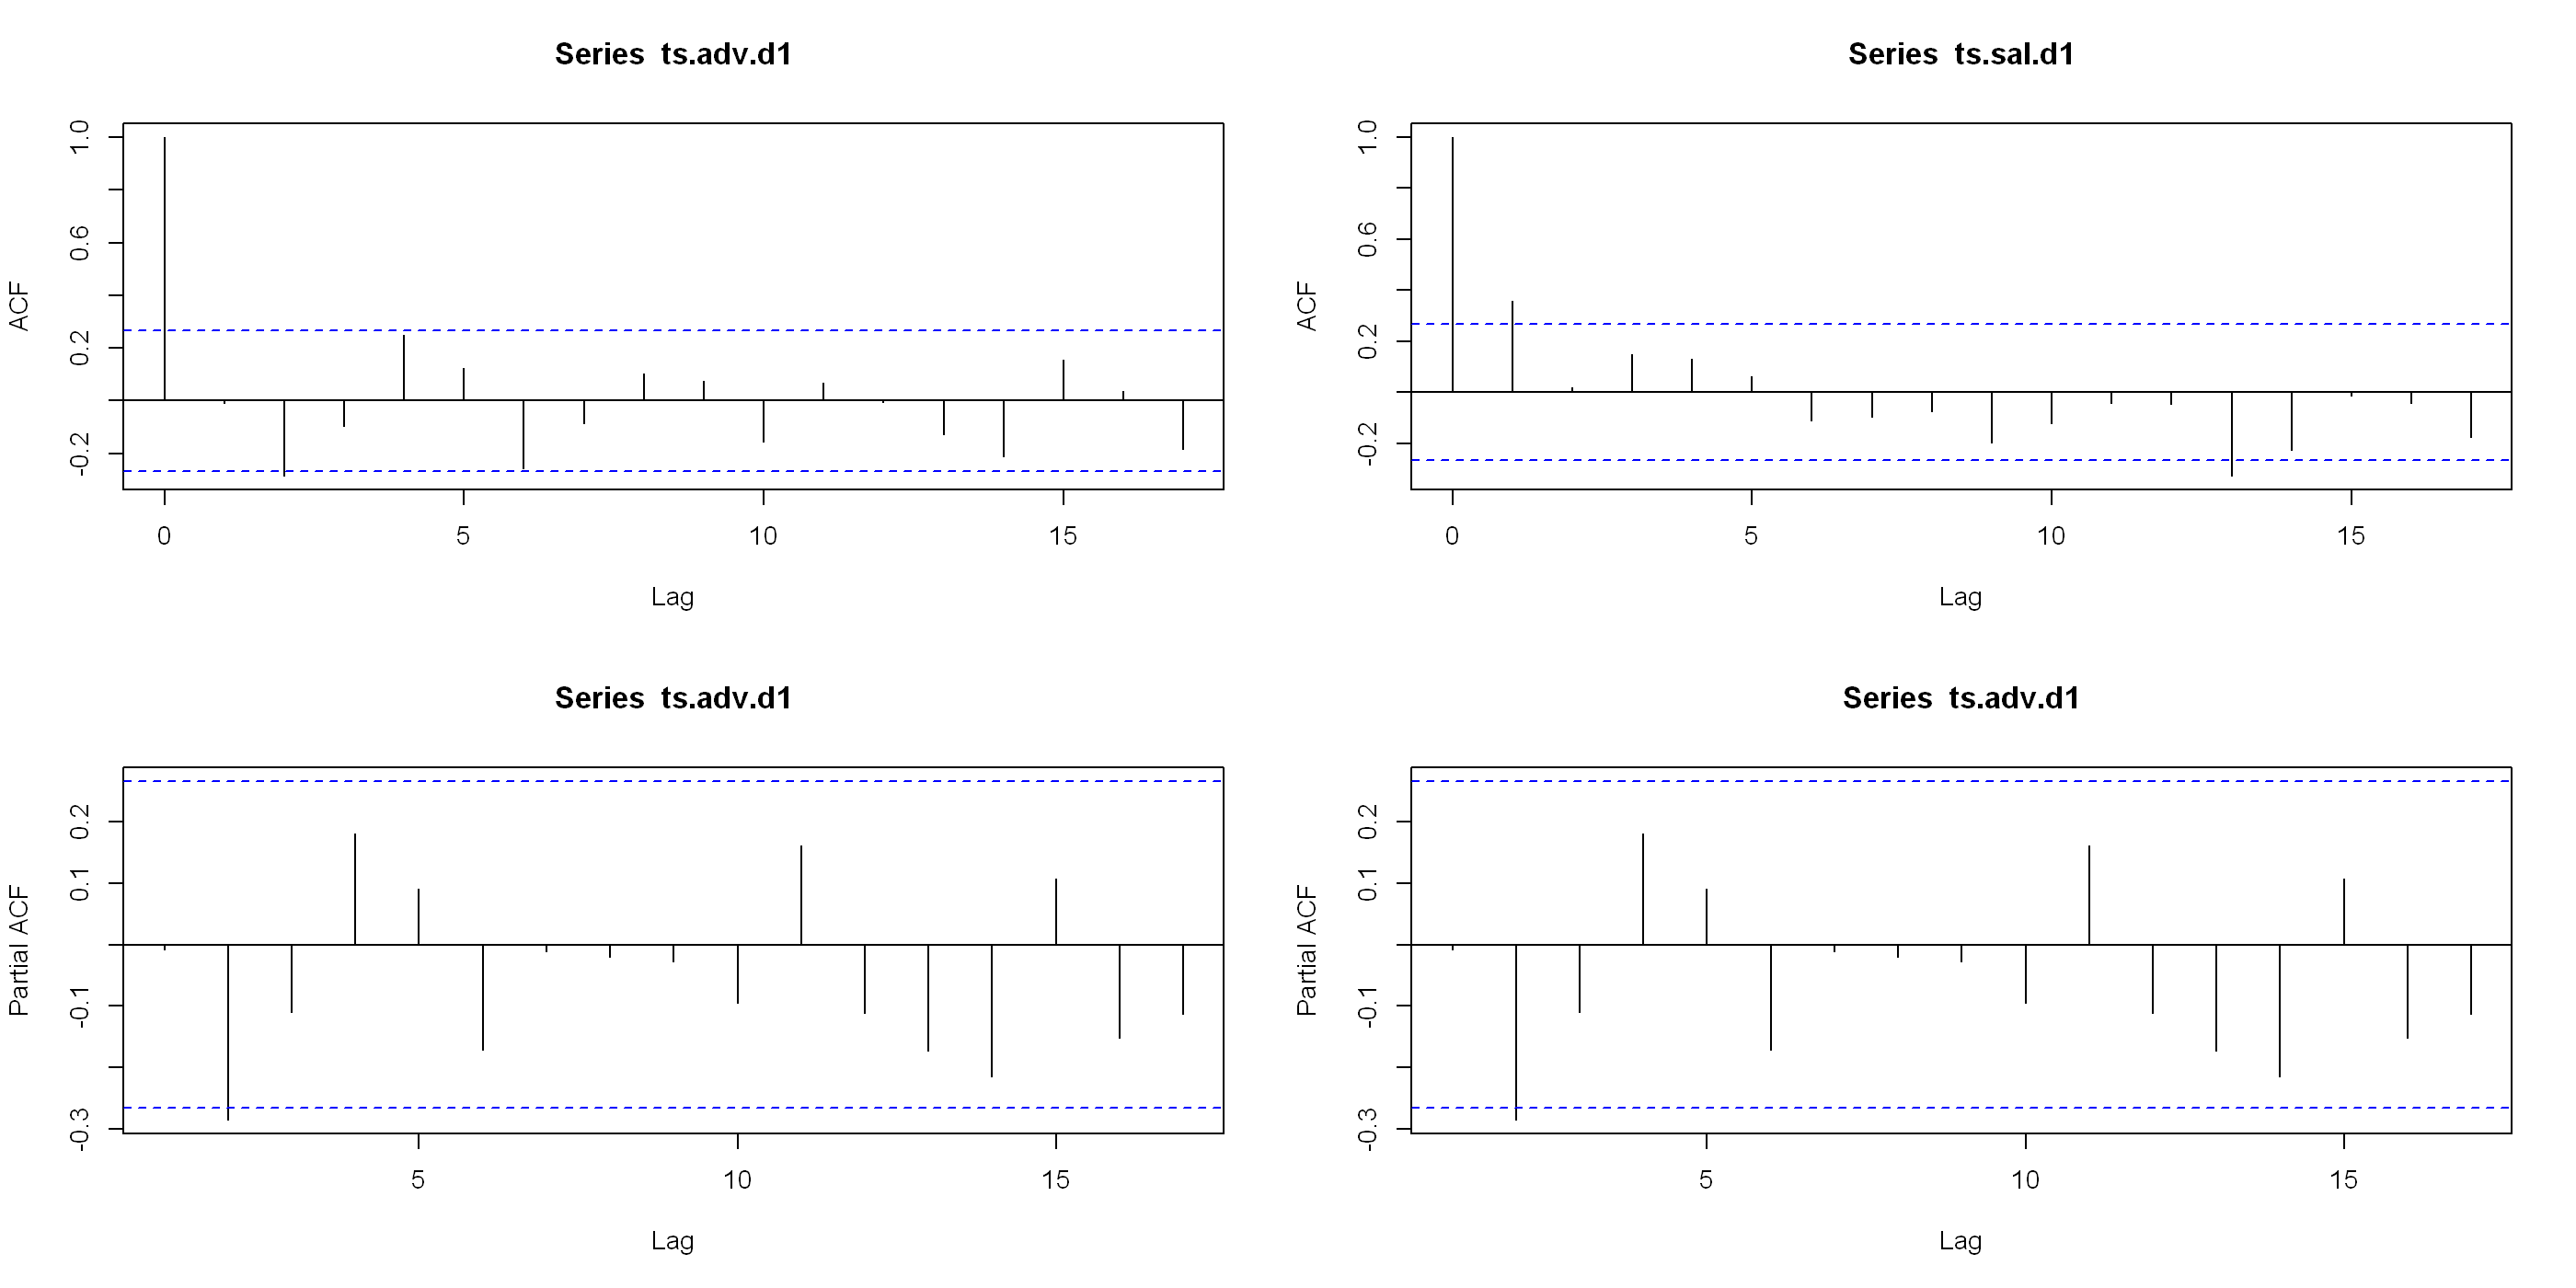

In [132]:
par(mfrow = c(2,2))
acf(ts.adv.d1,na.action = na.pass)
acf(ts.sal.d1,na.action = na.pass)
pacf(ts.adv.d1,na.action = na.pass)
pacf(ts.adv.d1,na.action = na.pass)

In [133]:
model <- arima(ts.adv.d1,order = c(2,0,0))

In [140]:
model


Call:
arima(x = ts.adv.d1, order = c(2, 0, 0))

Coefficients:
          ar1      ar2  intercept
      -0.0065  -0.2875    -0.0003
s.e.   0.1331   0.1314     0.0244

sigma^2 estimated as 0.05171:  log likelihood = 3.21,  aic = 1.59

In [134]:
model$coef[1:2]

ar1          ar2 
-0.006543172 -0.287537729

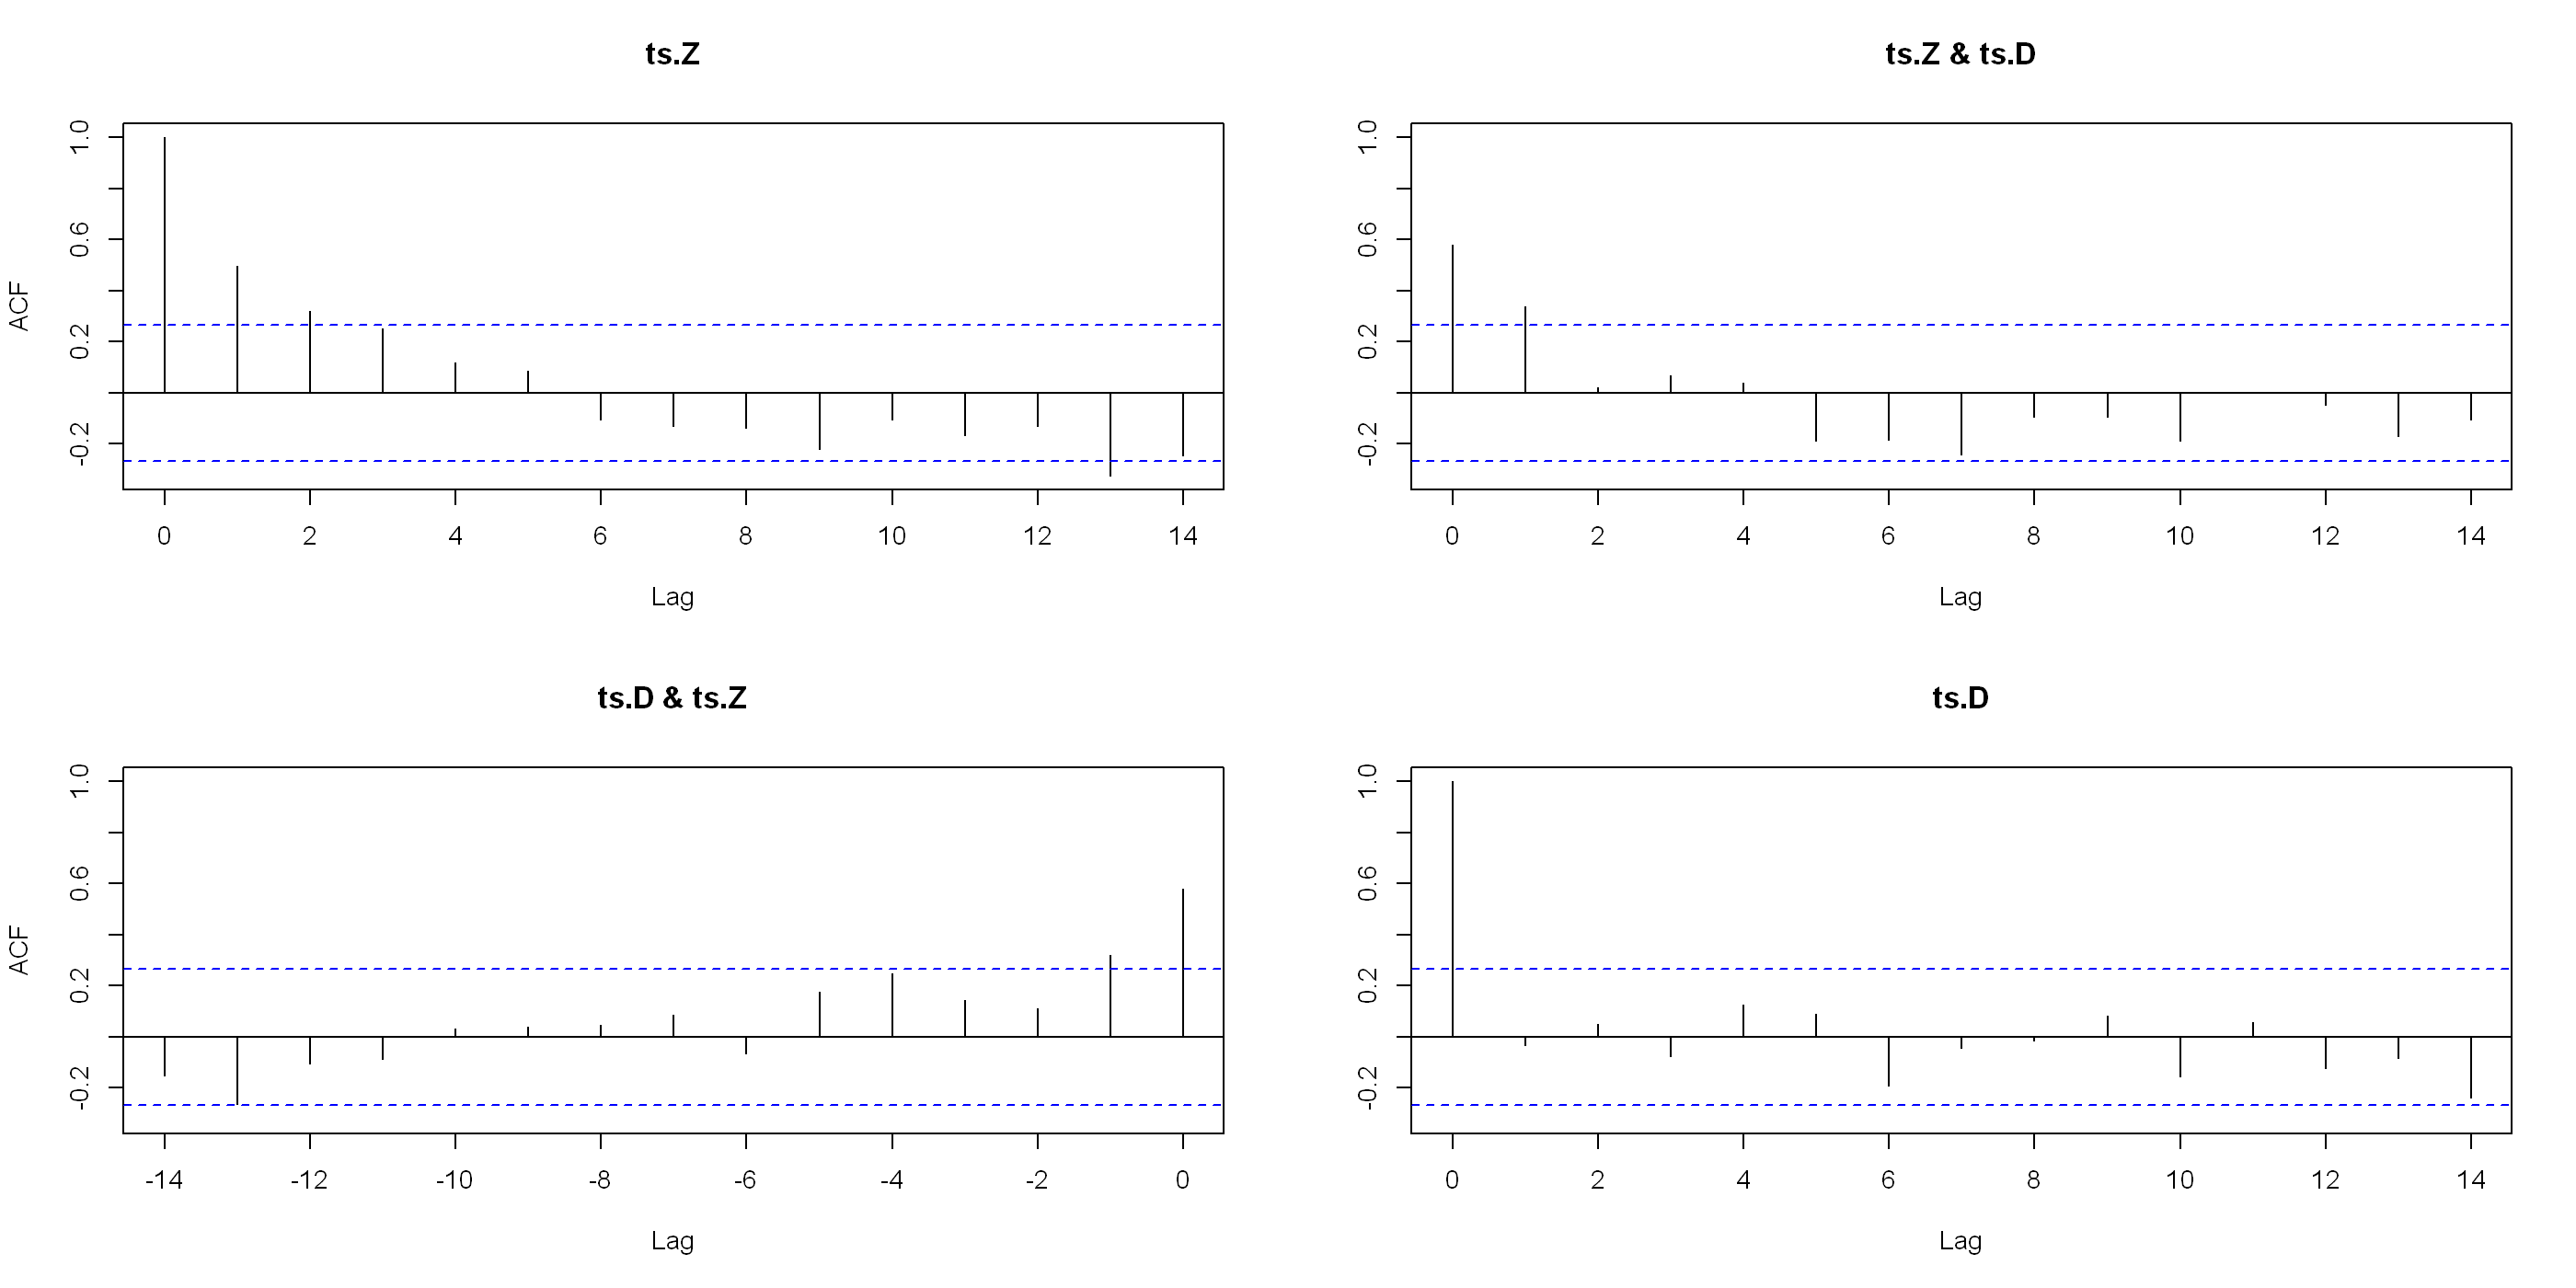

In [142]:
ts.D <- resid(model)
ts.Z <- filter(ts.sal.d1,c(1,-model$coef[1:2]),sides=1)
ts.trans <- ts.intersect(ts.Z, ts.D)

acf(ts.trans,na.action = na.pass)

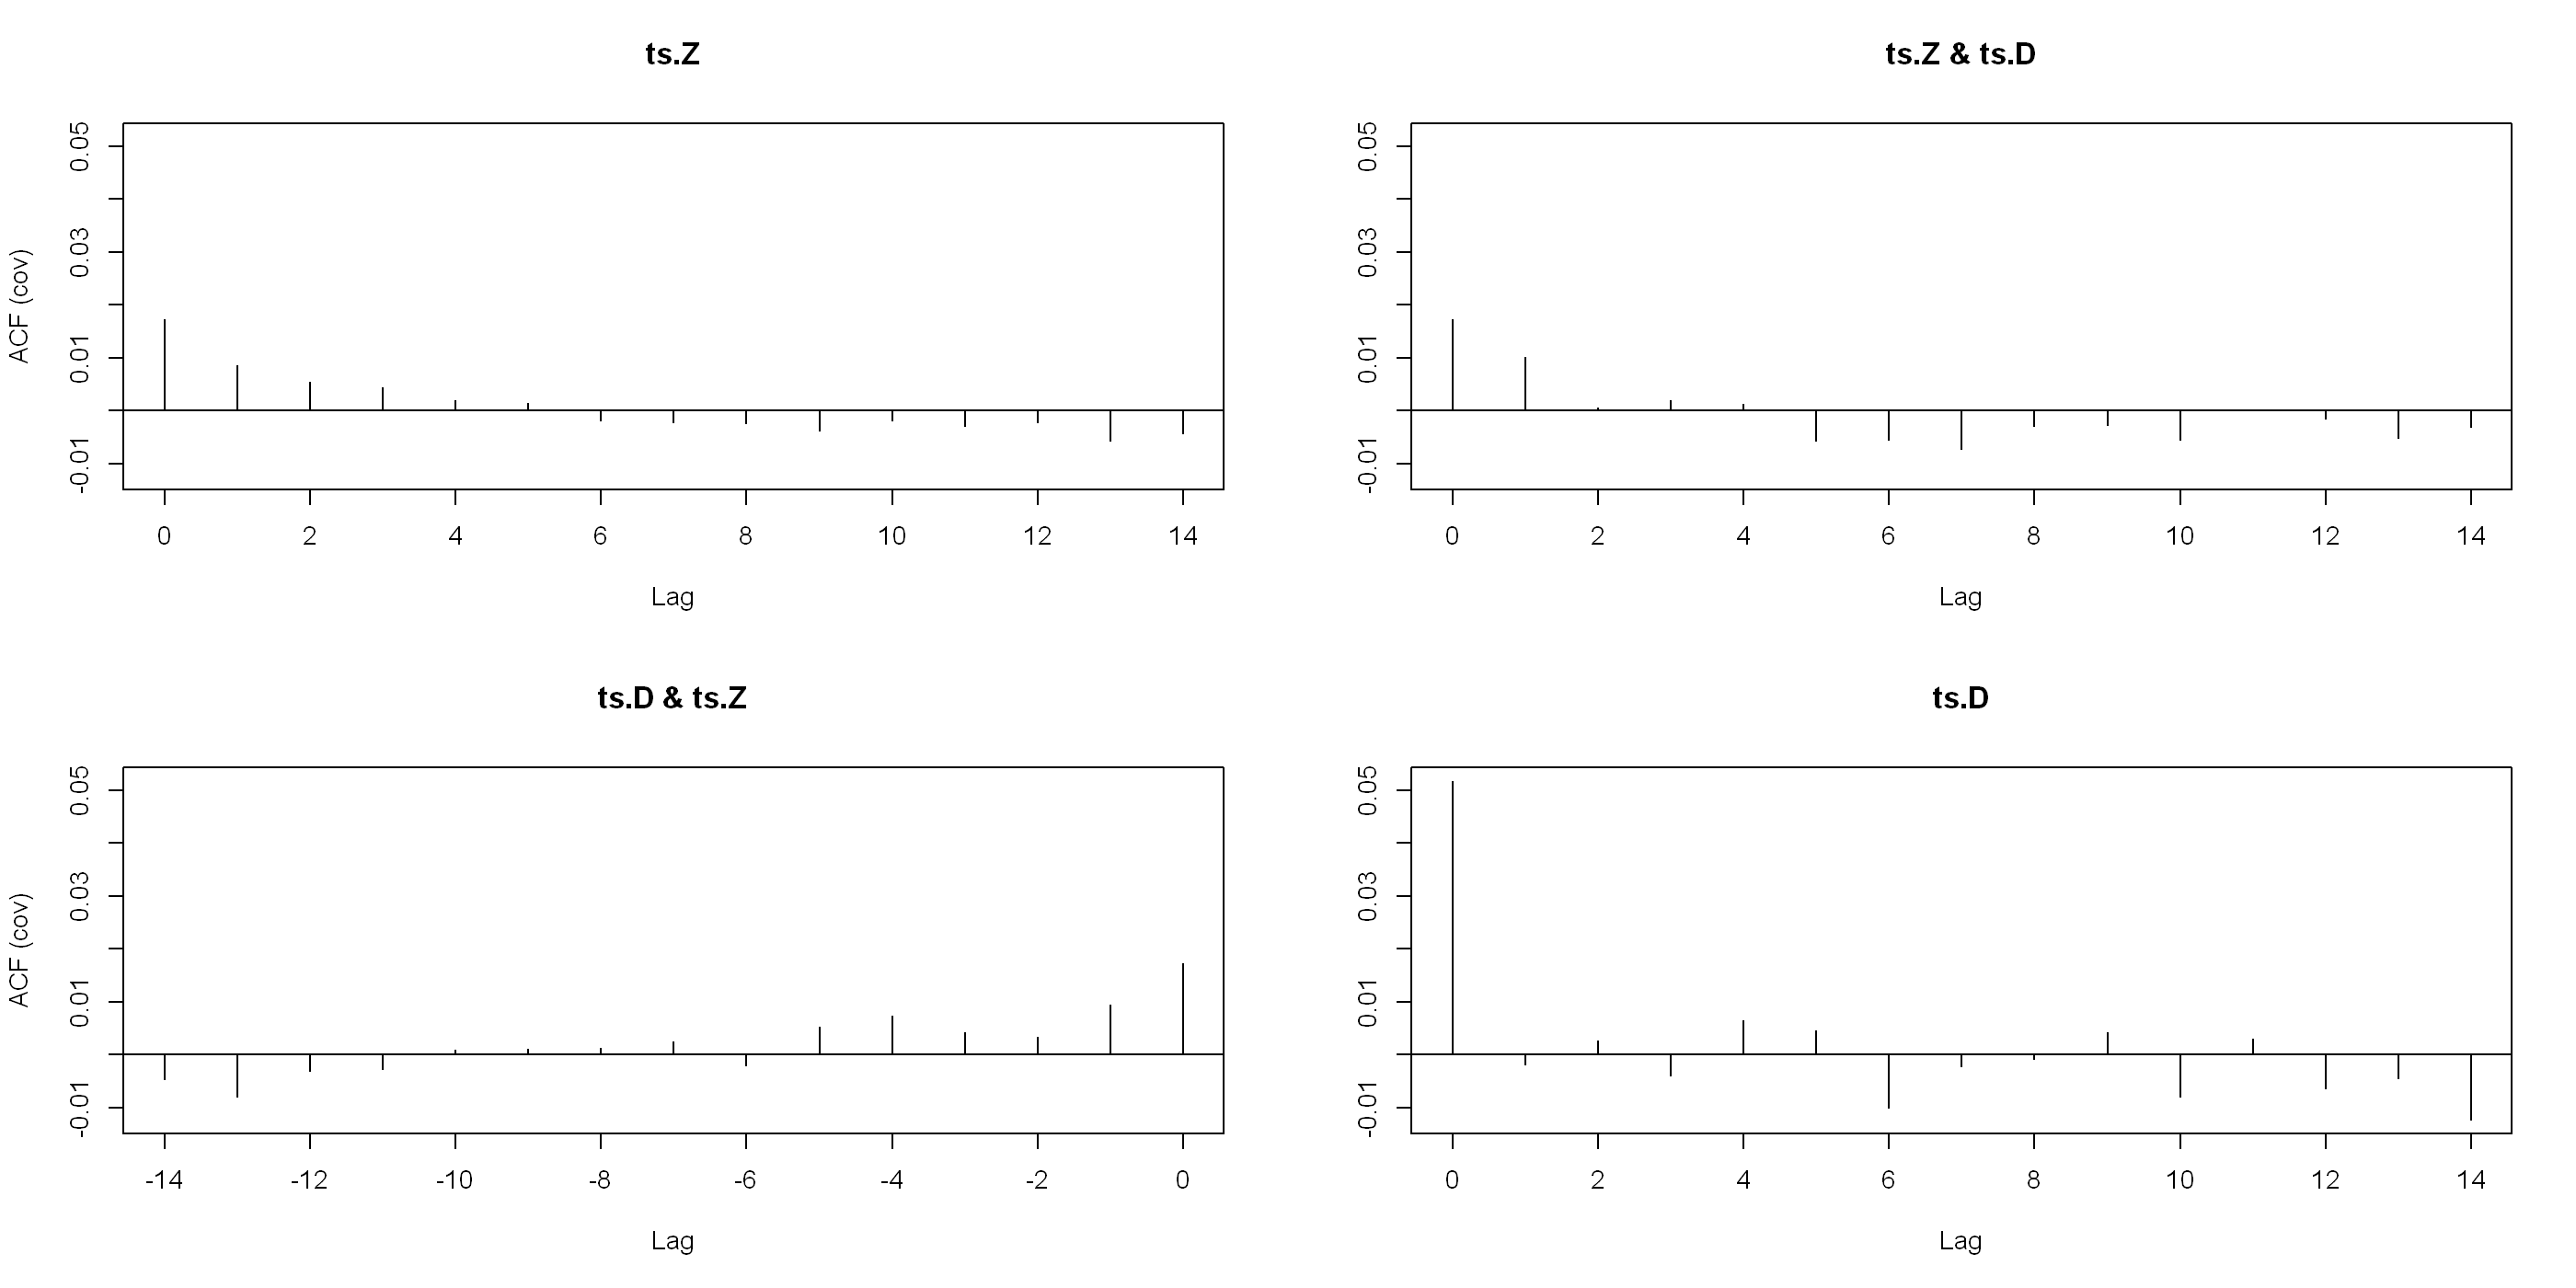

In [143]:
gamma <- acf(ts.trans,na.action = na.pass,type="covariance")

In [144]:
gamma_21 <- gamma$acf[,1,2]
gamma_110 <- gamma$acf[1,2,2]

In [145]:
nu_k <- gamma_21/gamma_110

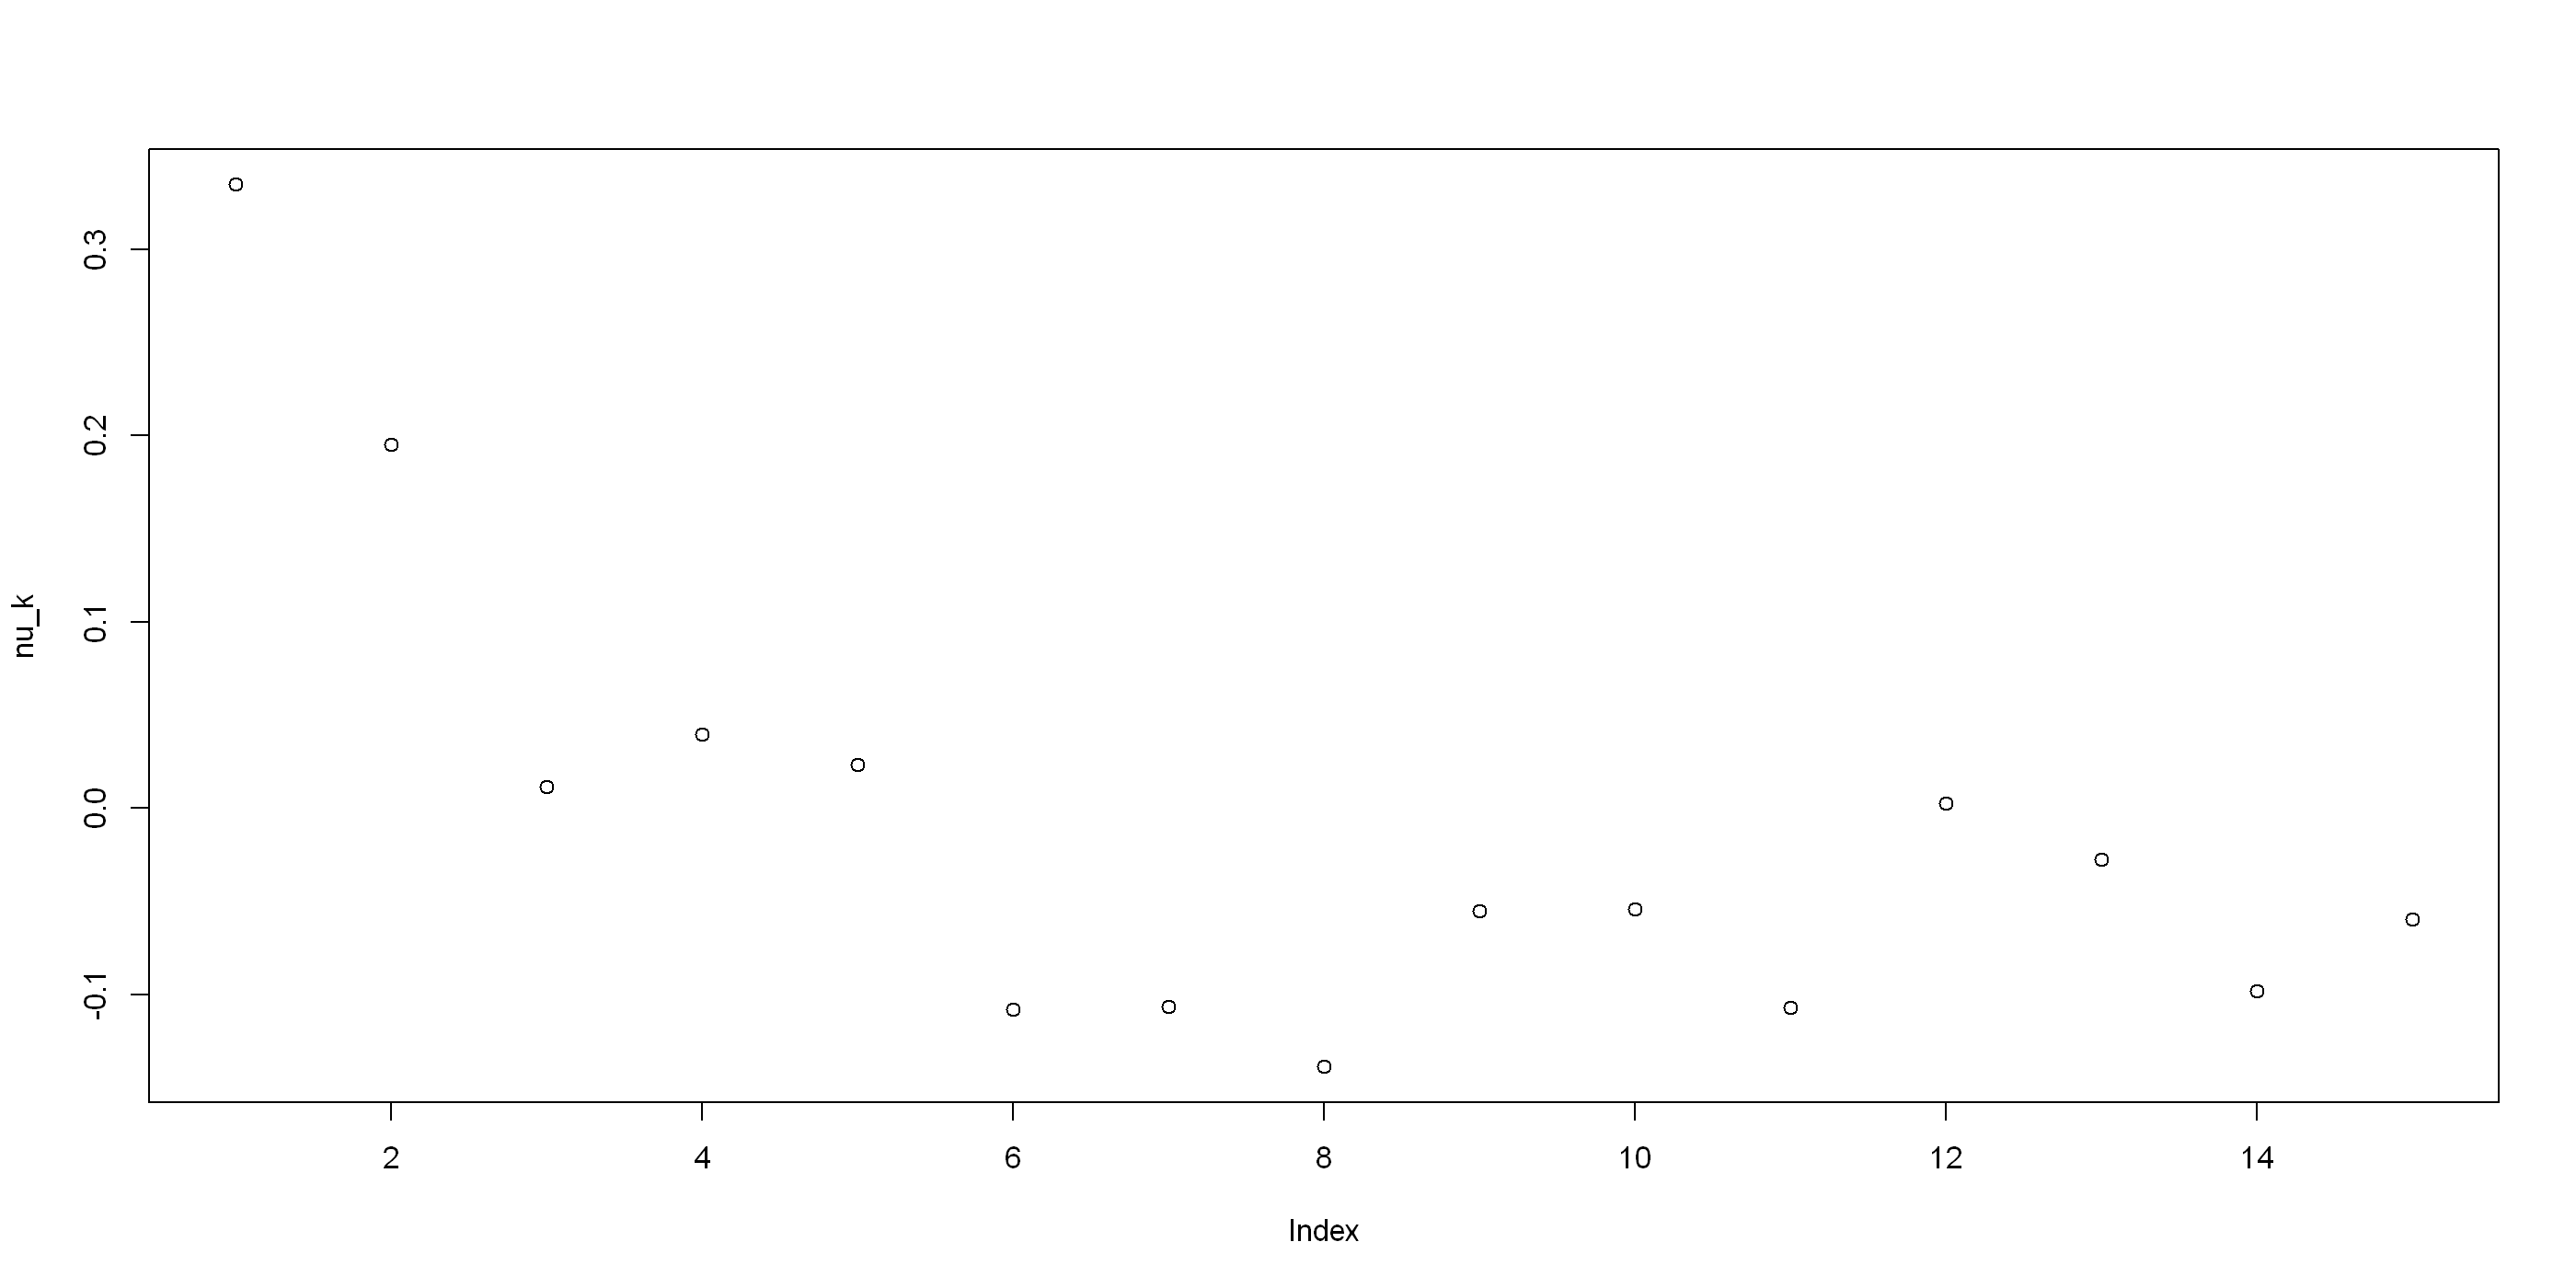

In [146]:
plot(nu_k)

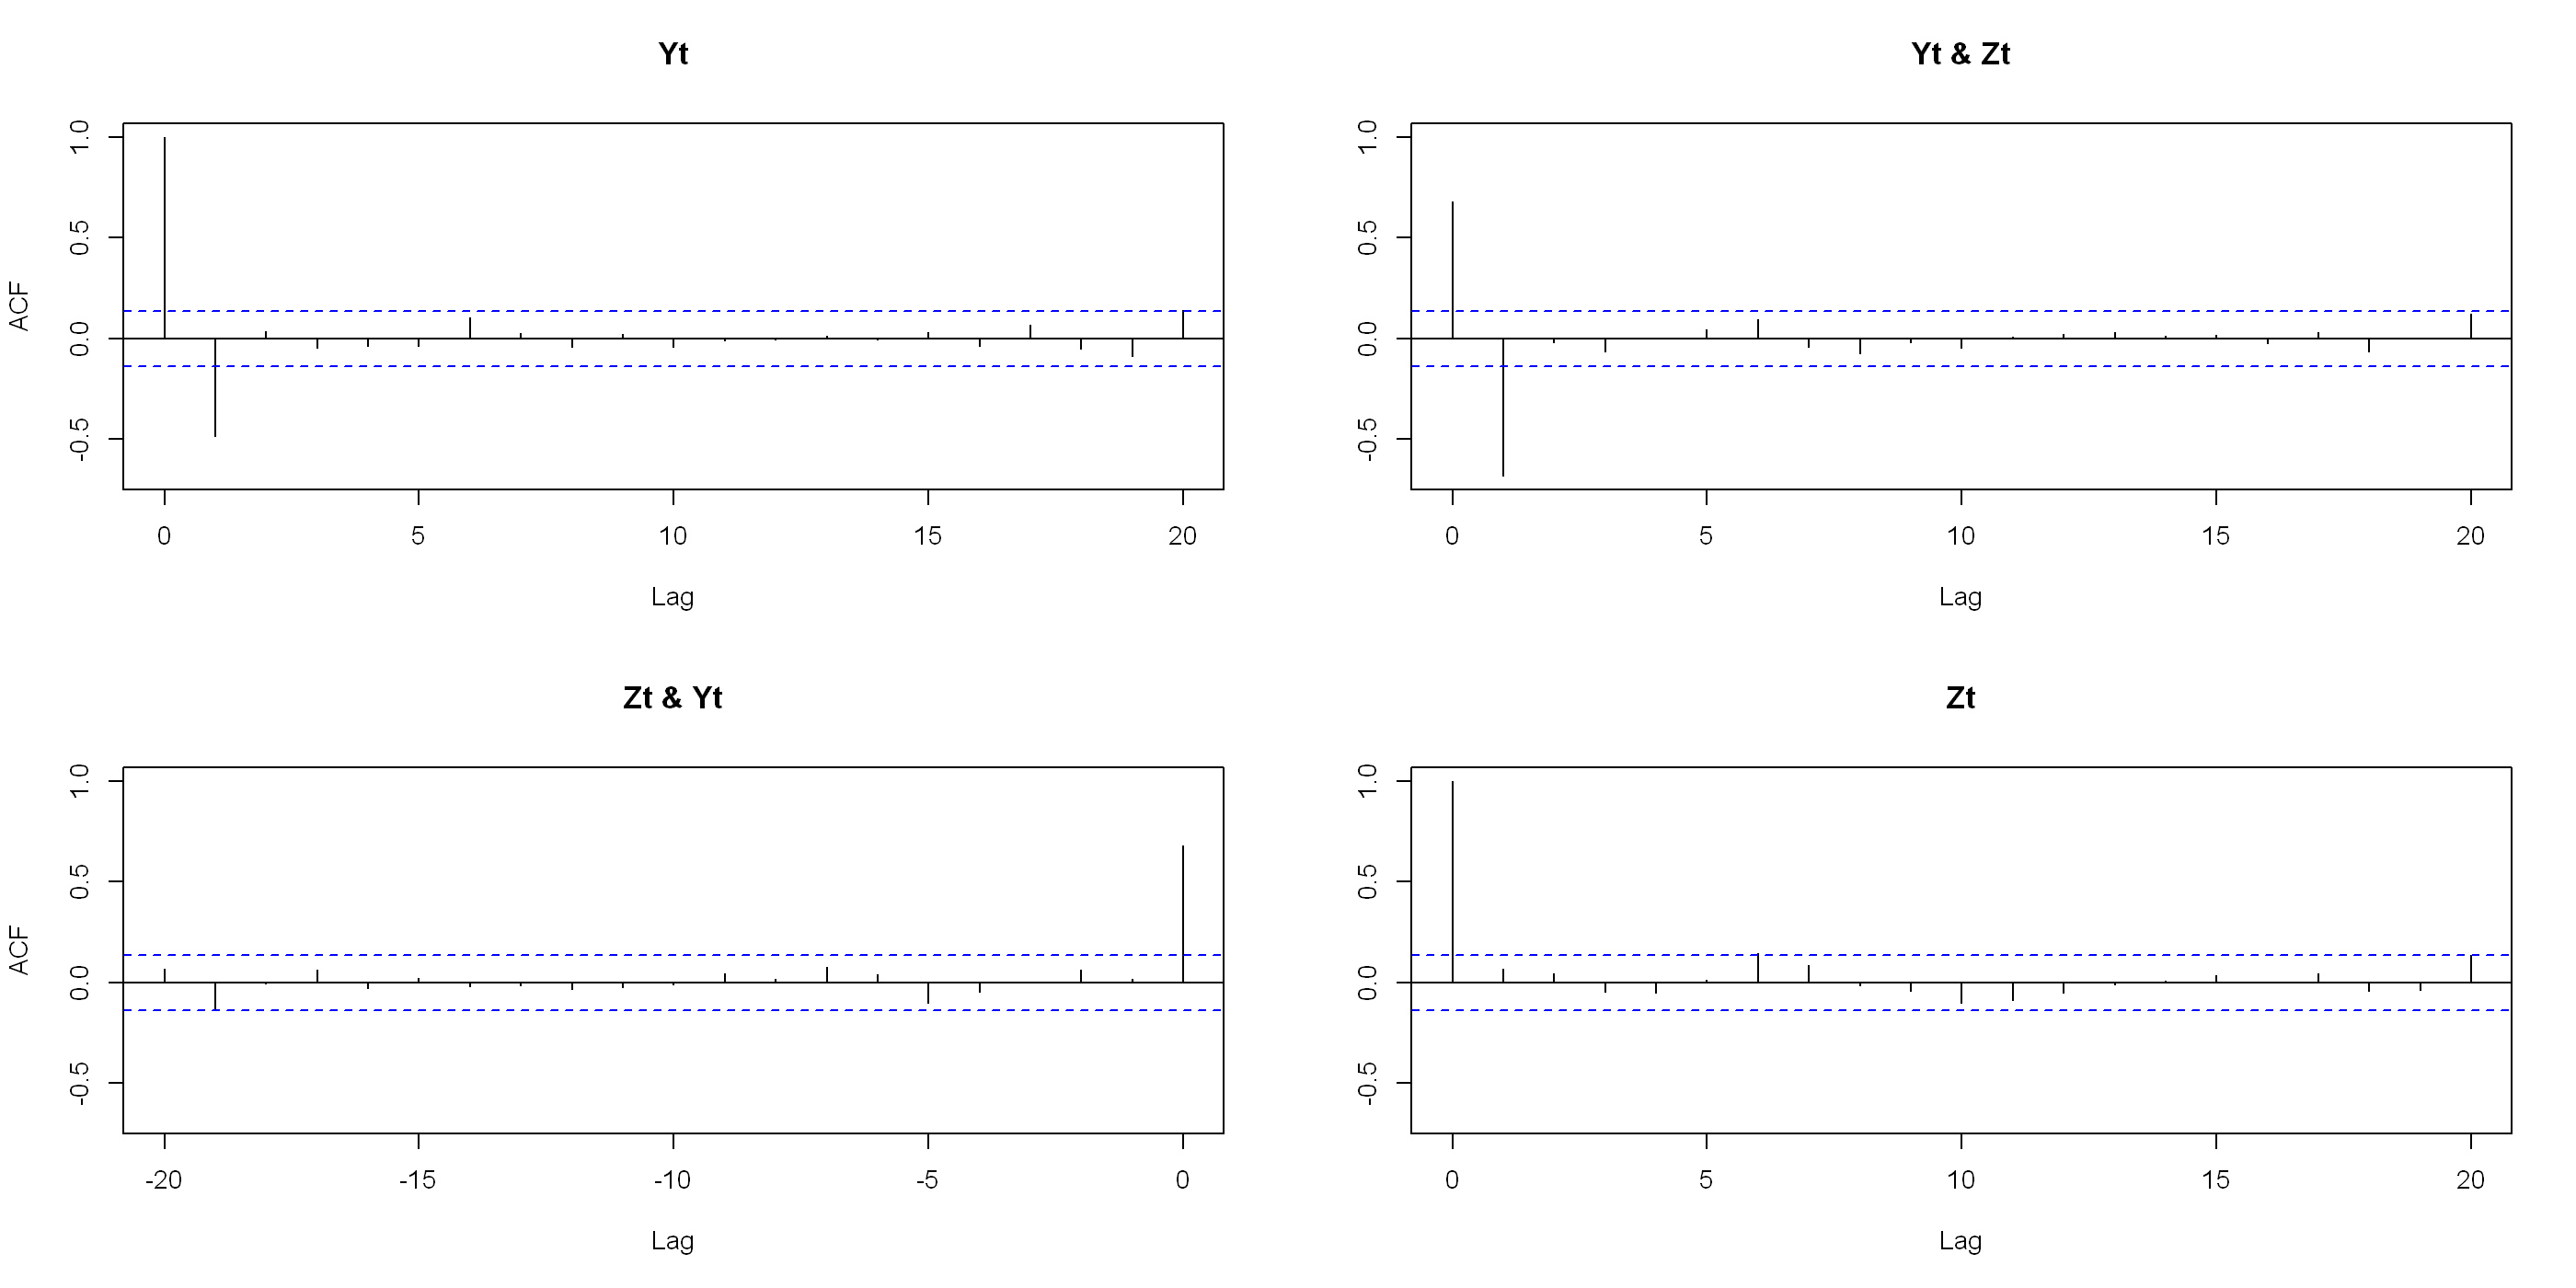

In [210]:
Et <- ts(rnorm(201))
Xt <- (1:201)+Et
Yt <- (diff(Xt))
Zt <- (Xt-(1:201))

YZ <- ts.intersect(Yt,Zt)
acf(YZ)

In [165]:
acf(YZ,na.action = na.pass,plot = F)$acf[,2,1]

[1] -0.6894558030  0.6978483364  0.0419661118  0.0651366139 -0.1240888646
 [6]  0.0488020497 -0.0184423693  0.0878310846 -0.1309297890  0.0461052074
[11] -0.0201481411  0.0829098648 -0.0522135521 -0.0802628767  0.1033208956
[16] -0.0003310494 -0.1031560157  0.0331635531  0.0579696303  0.1157200988
[21] -0.1632712995

In [211]:
ts.ocwave <- ts(scan("http://stat.ethz.ch/Teaching/Datasets/WBL/ocwave.dat"),
start = 1, frequency = 4)

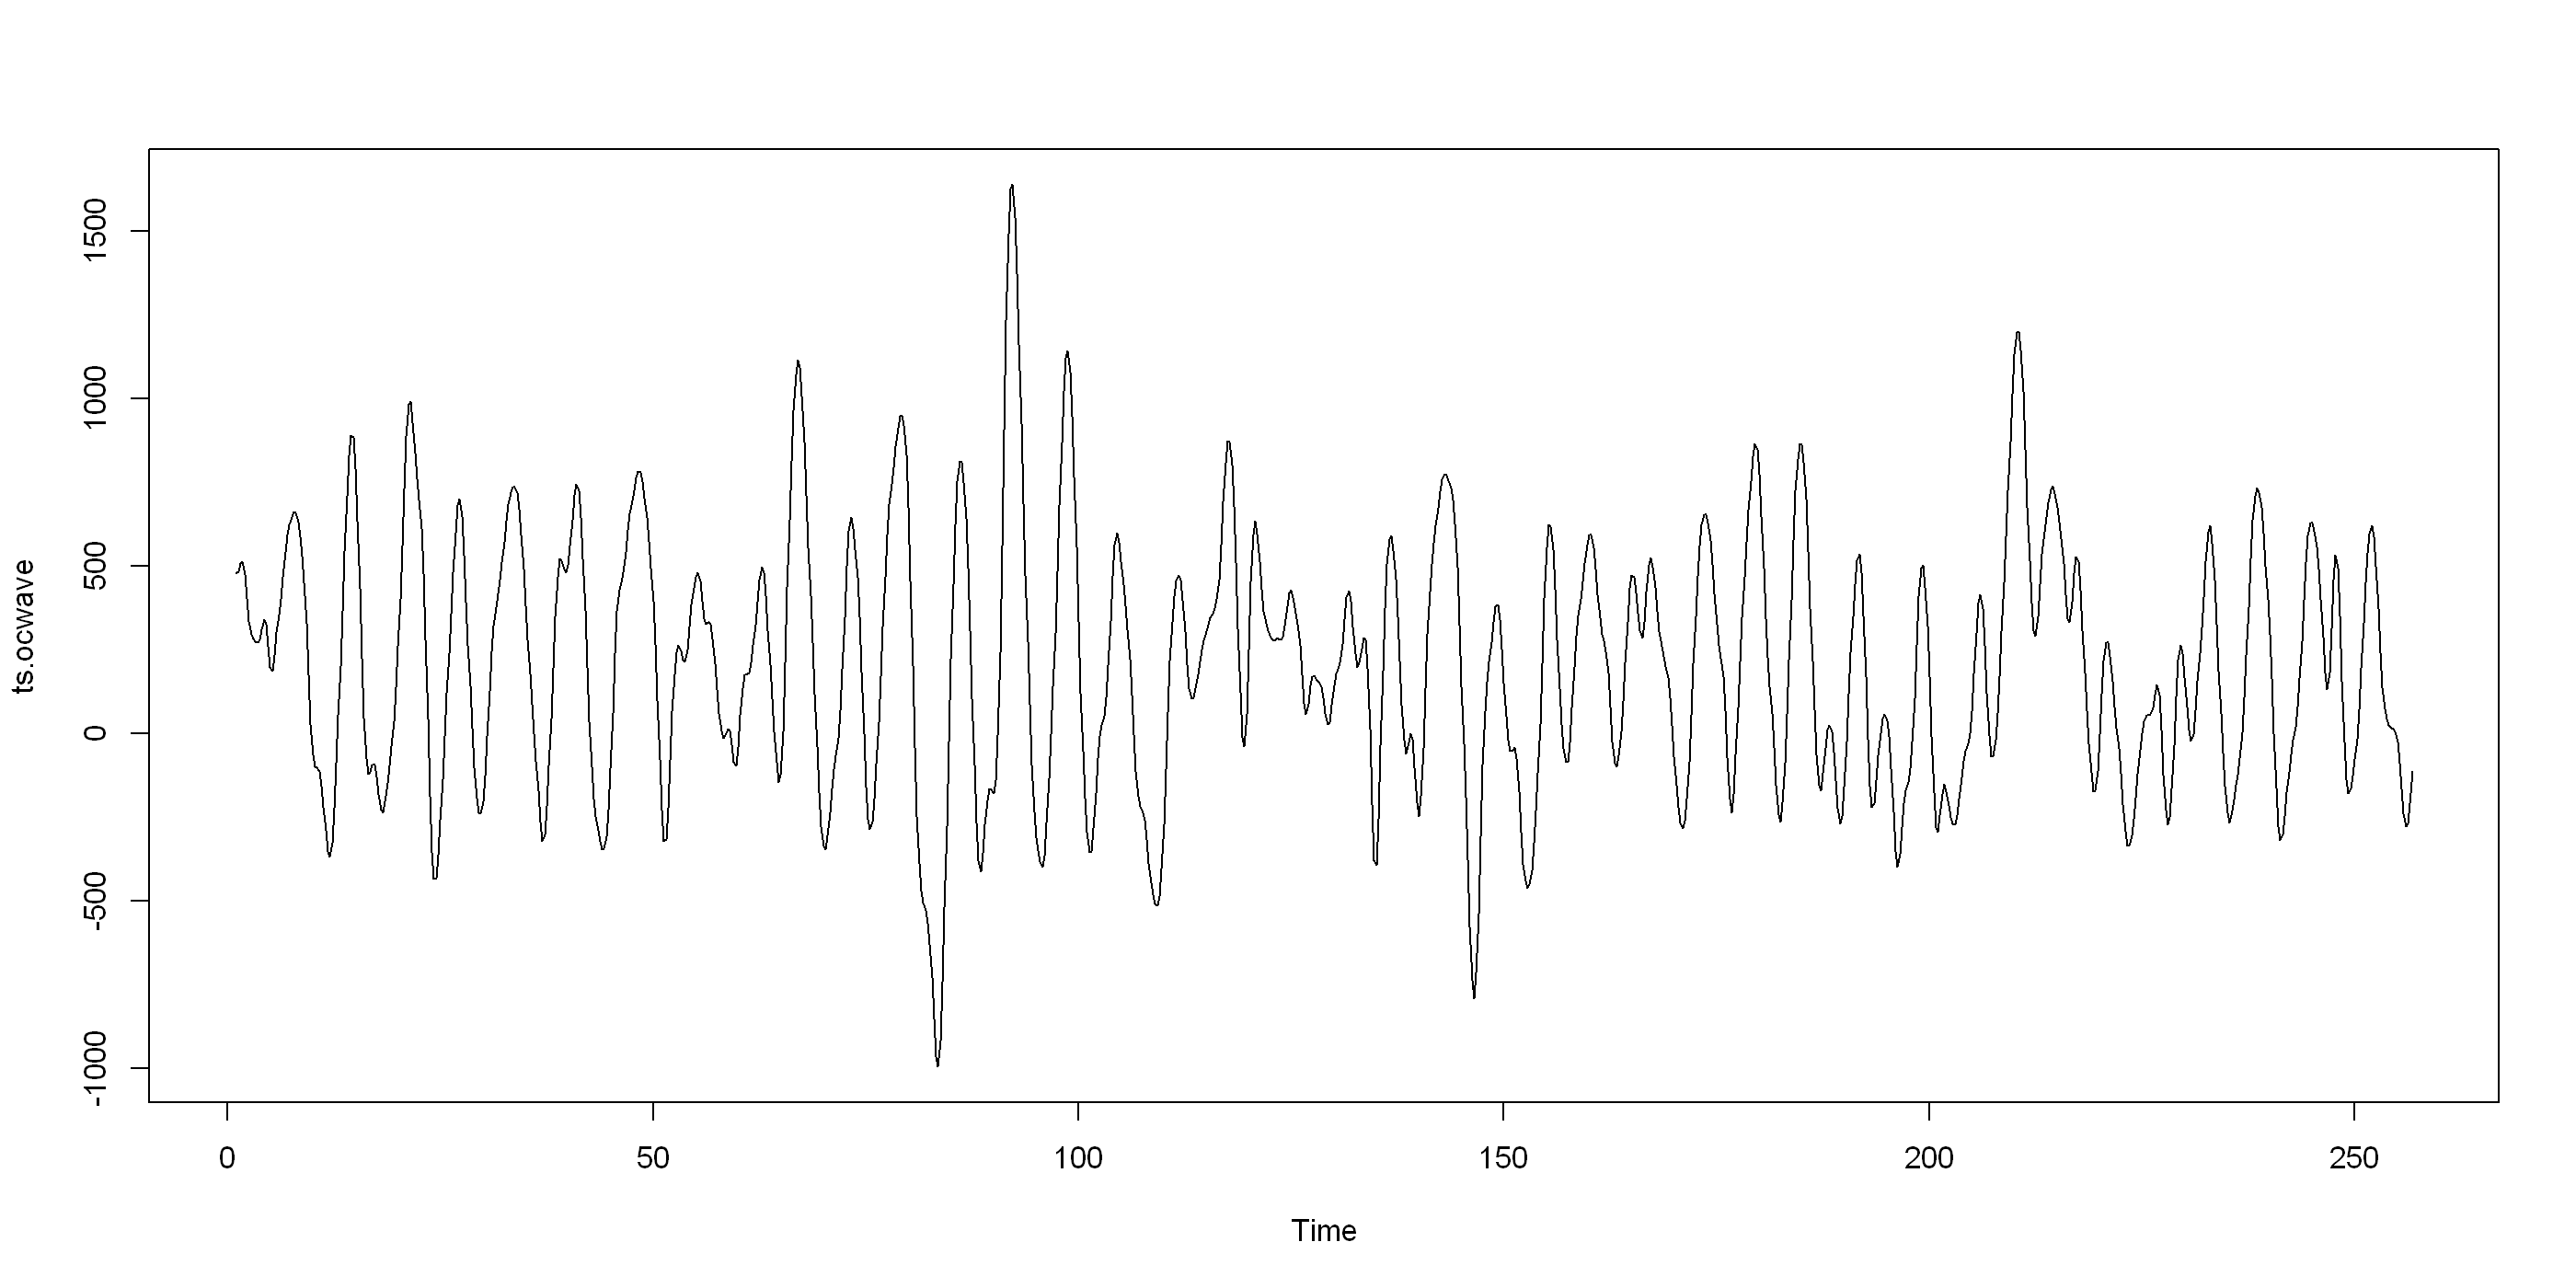

In [212]:
plot(ts.ocwave)

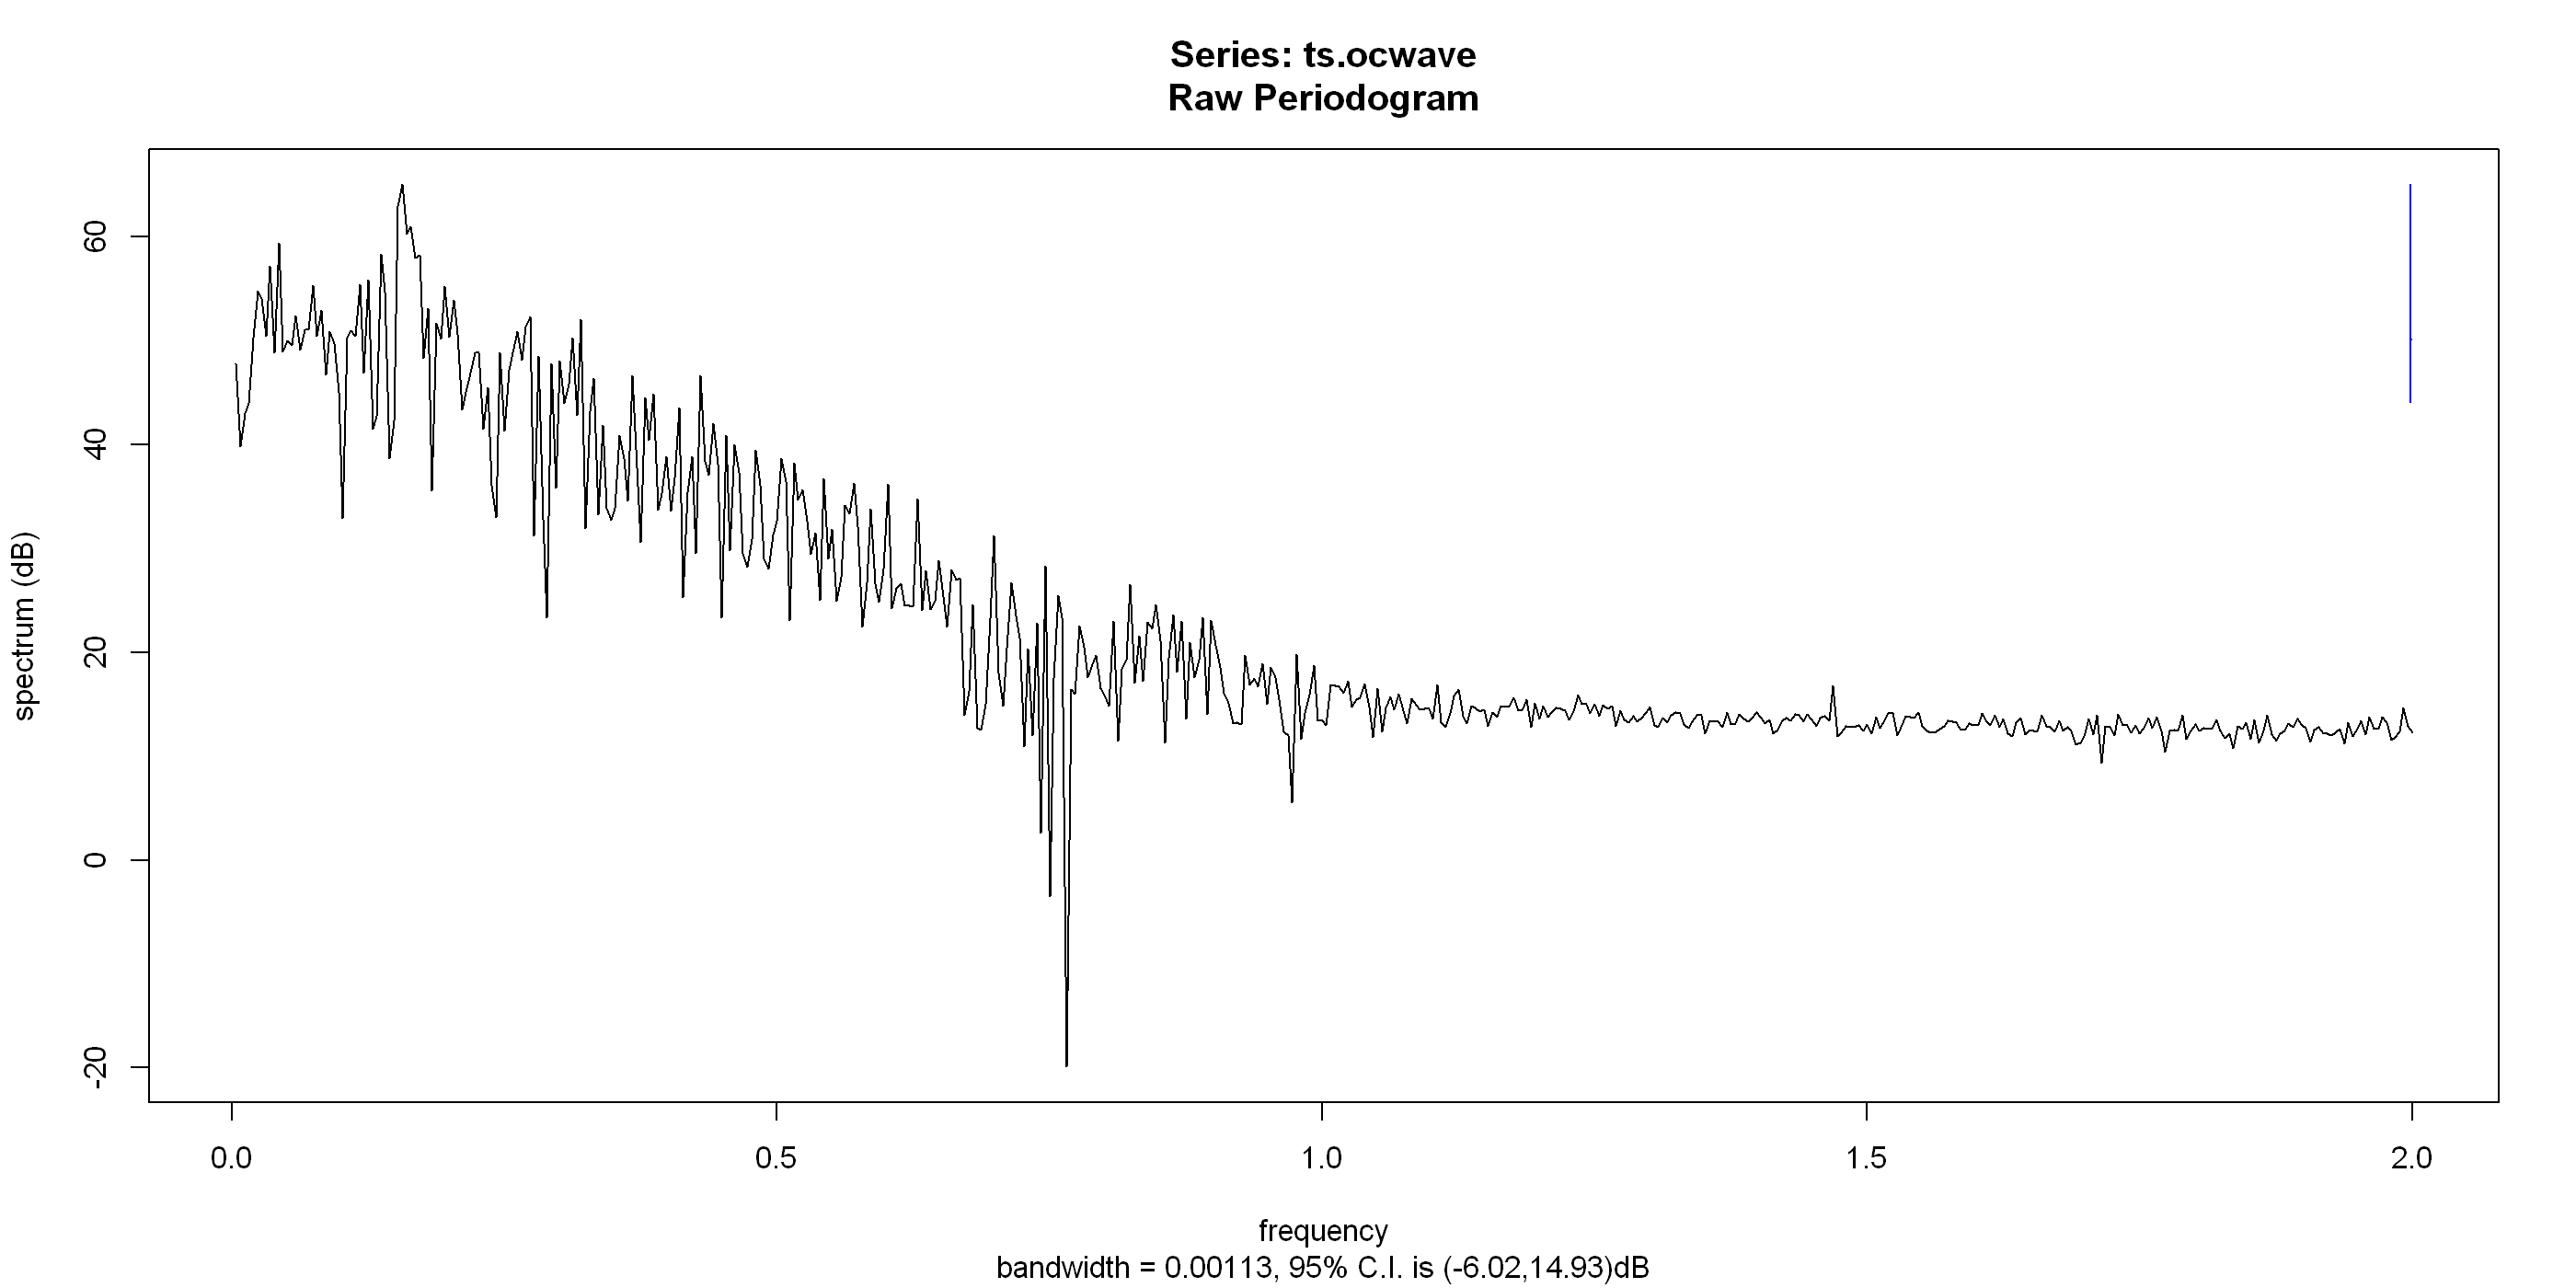

In [213]:
spec.pgram(ts.ocwave, taper = F, detrend = FALSE, demean = TRUE, log = "dB")


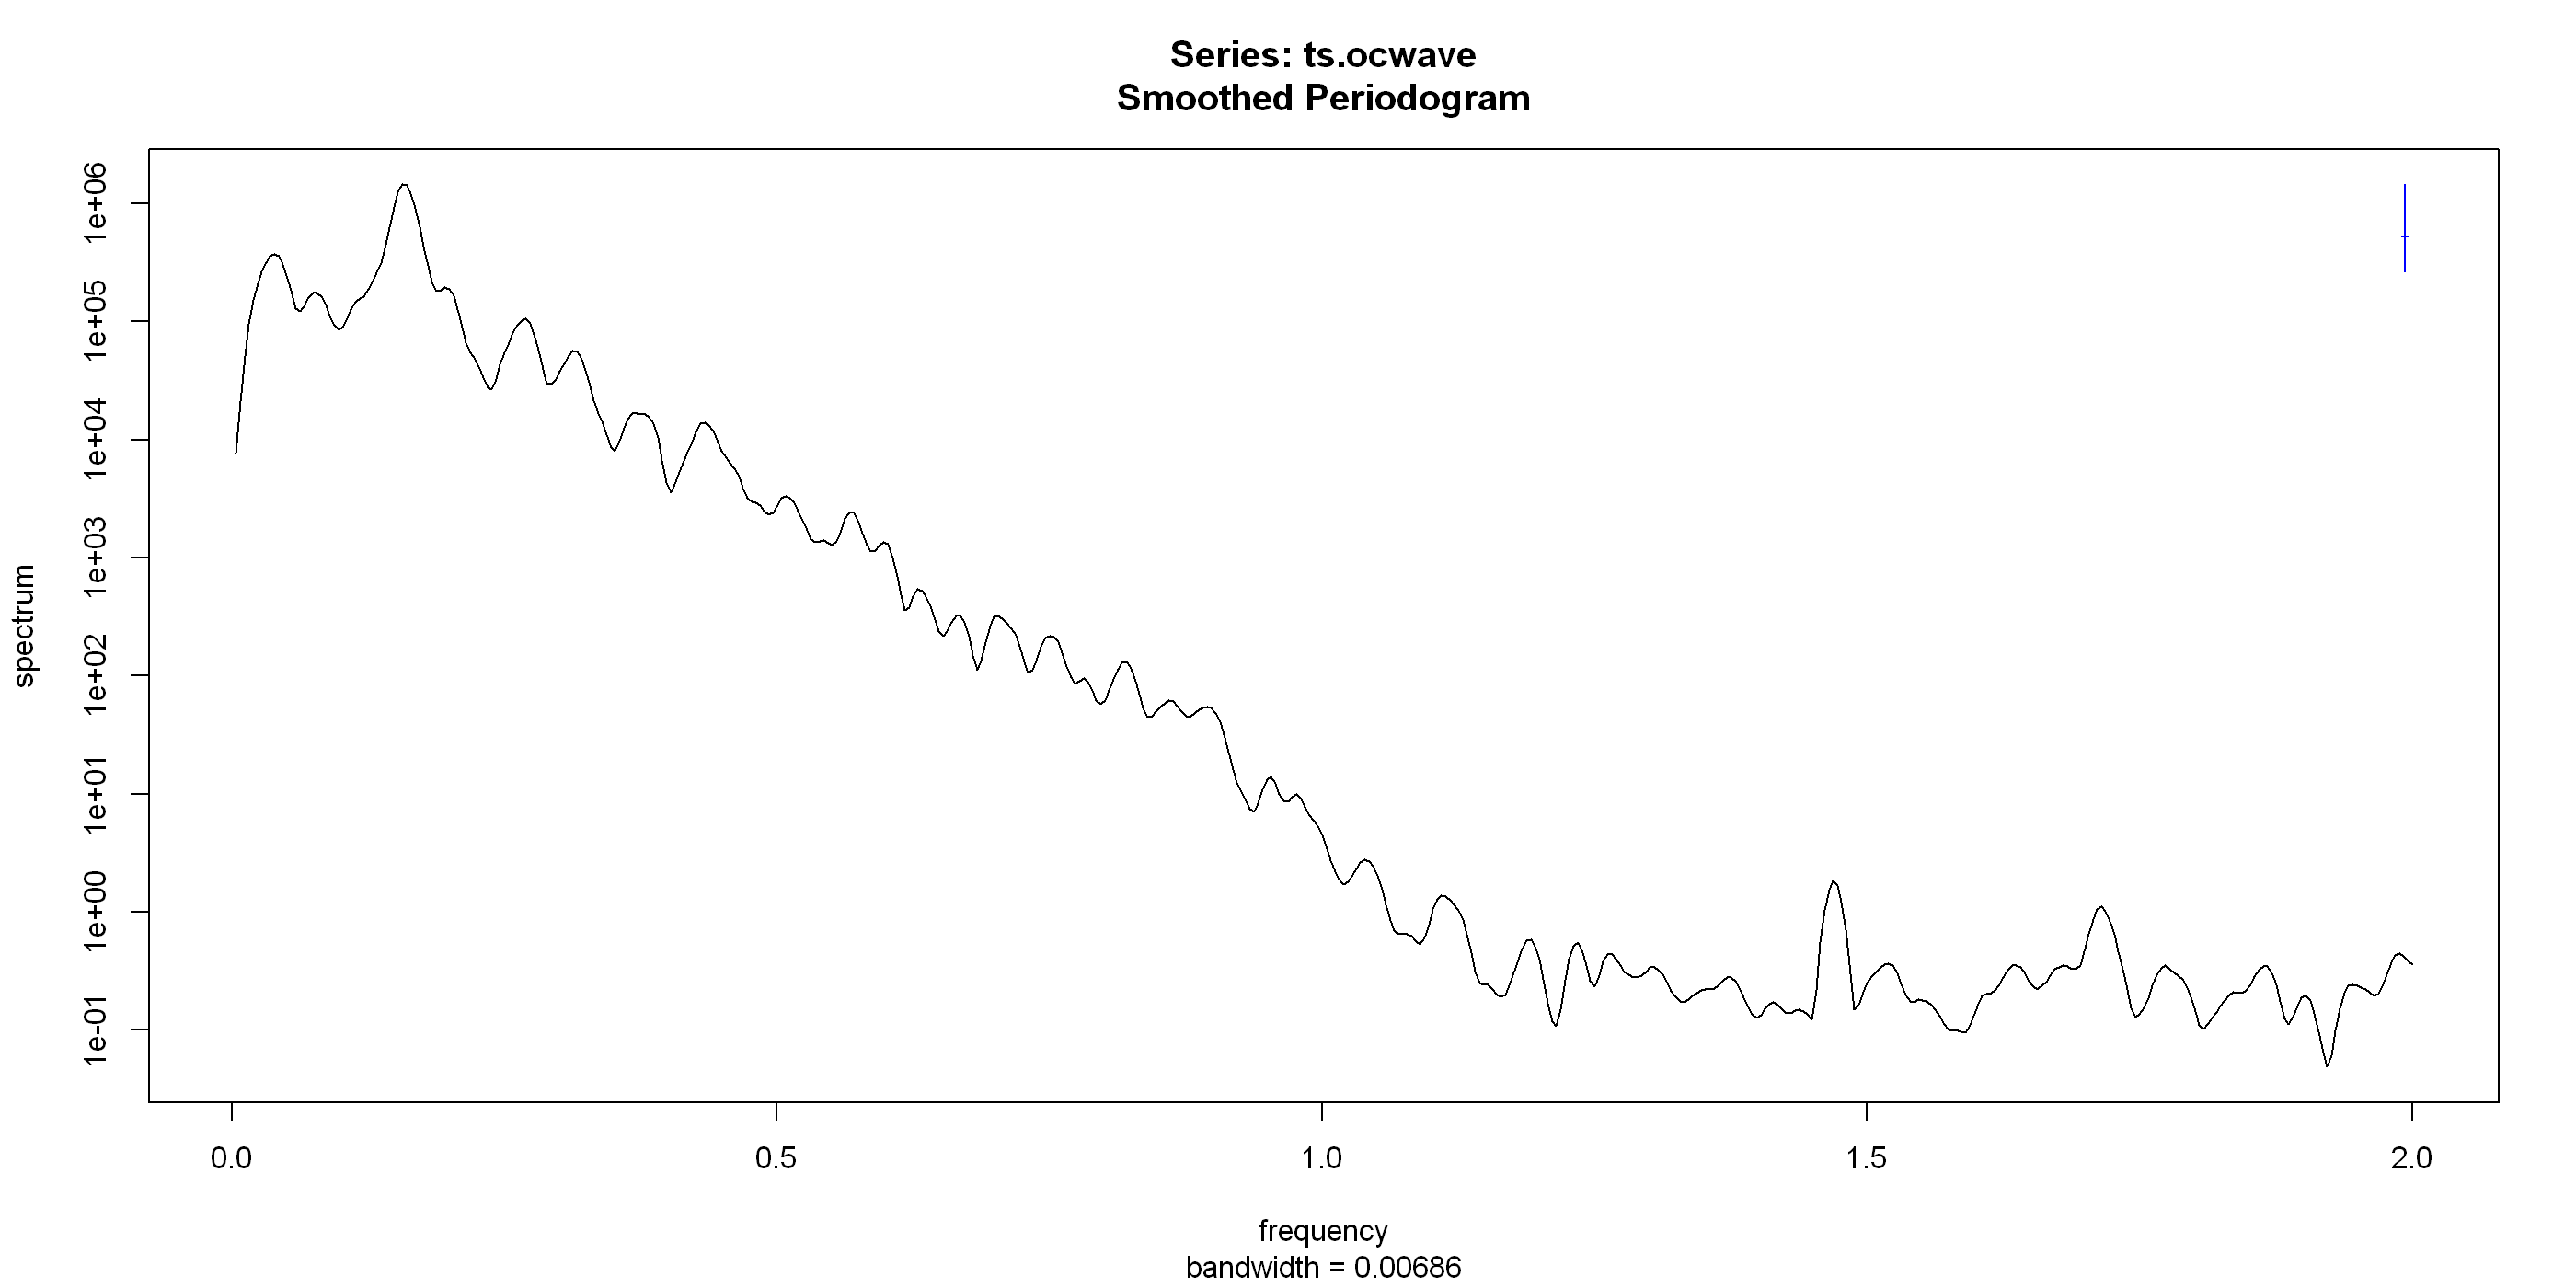

In [231]:
spec.pgram(x = ts.ocwave,spans = c(5,5))

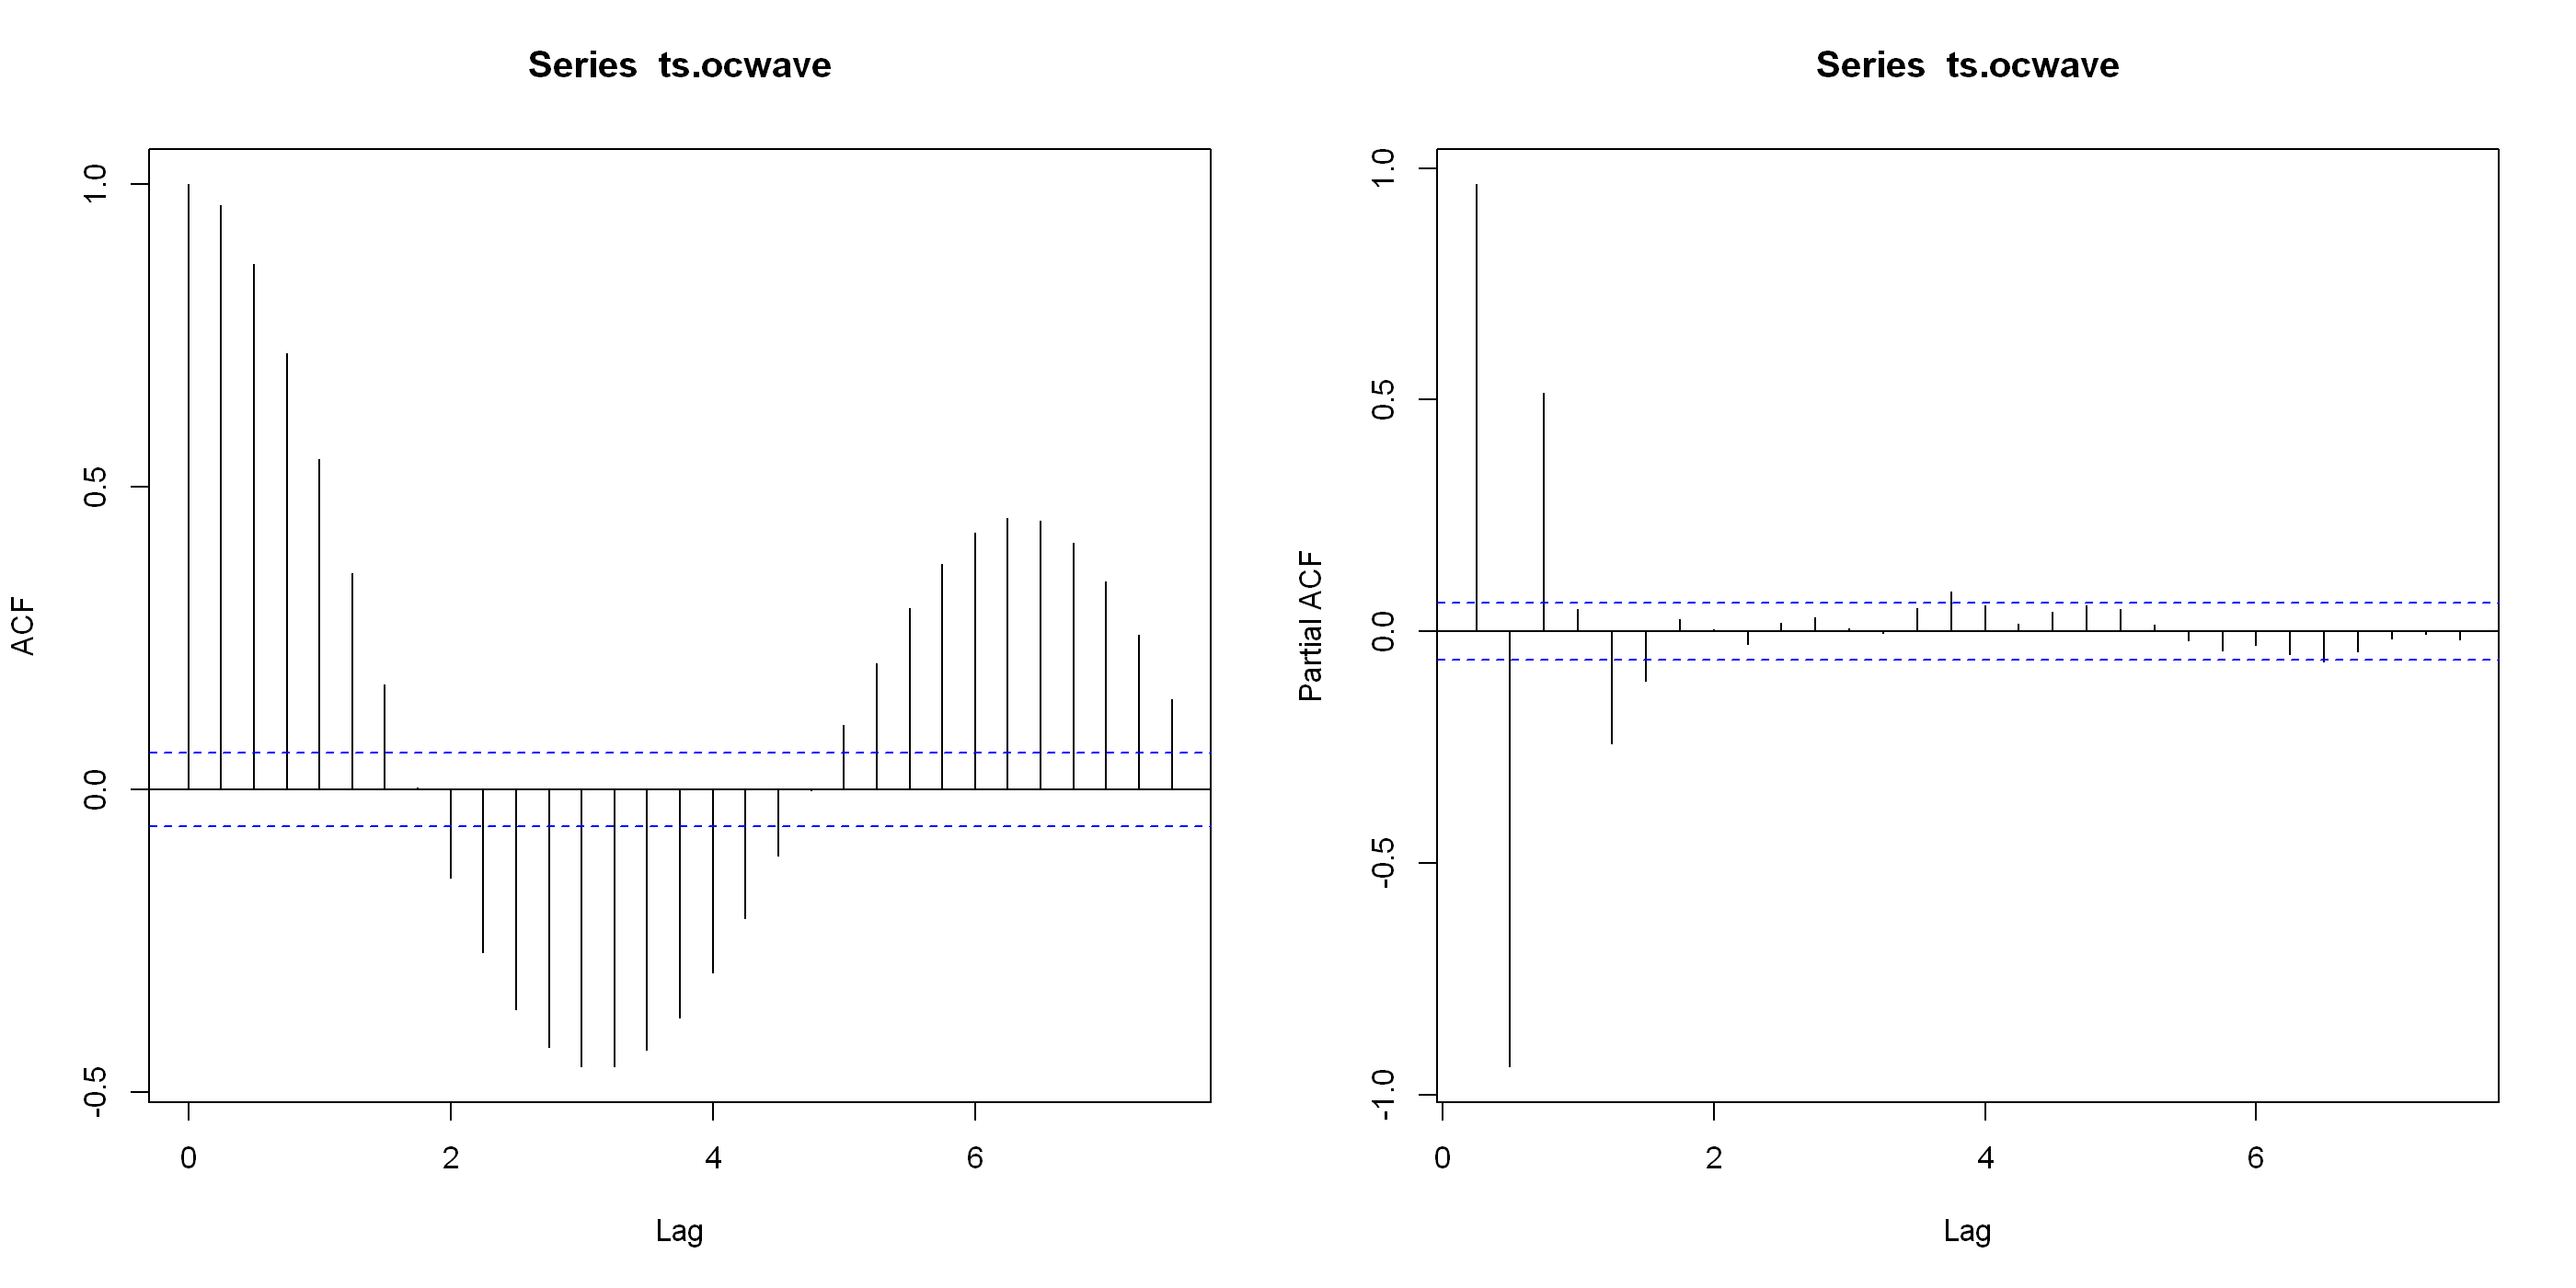

In [232]:
par(mfrow=c(1,2))
acf(ts.ocwave)
pacf(ts.ocwave)

In [235]:
ocwave.yw <- ar.yw(ts.ocwave, aic = FALSE, order = 5)
ocwave.burg <- ar.burg(ts.ocwave, aic = FALSE, order = 5)


In [236]:
ocwave.yw


Call:
ar.yw.default(x = ts.ocwave, aic = FALSE, order.max = 5)

Coefficients:
      1        2        3        4        5  
 2.3415  -1.7129  -0.0375   0.6122  -0.2421  

Order selected 5  sigma^2 estimated as  805.7

In [237]:
ocwave.burg


Call:
ar.burg.default(x = ts.ocwave, aic = FALSE, order.max = 5)

Coefficients:
      1        2        3        4        5  
 3.4194  -4.9926   3.9268  -1.6671   0.2967  

Order selected 5  sigma^2 estimated as  149.7

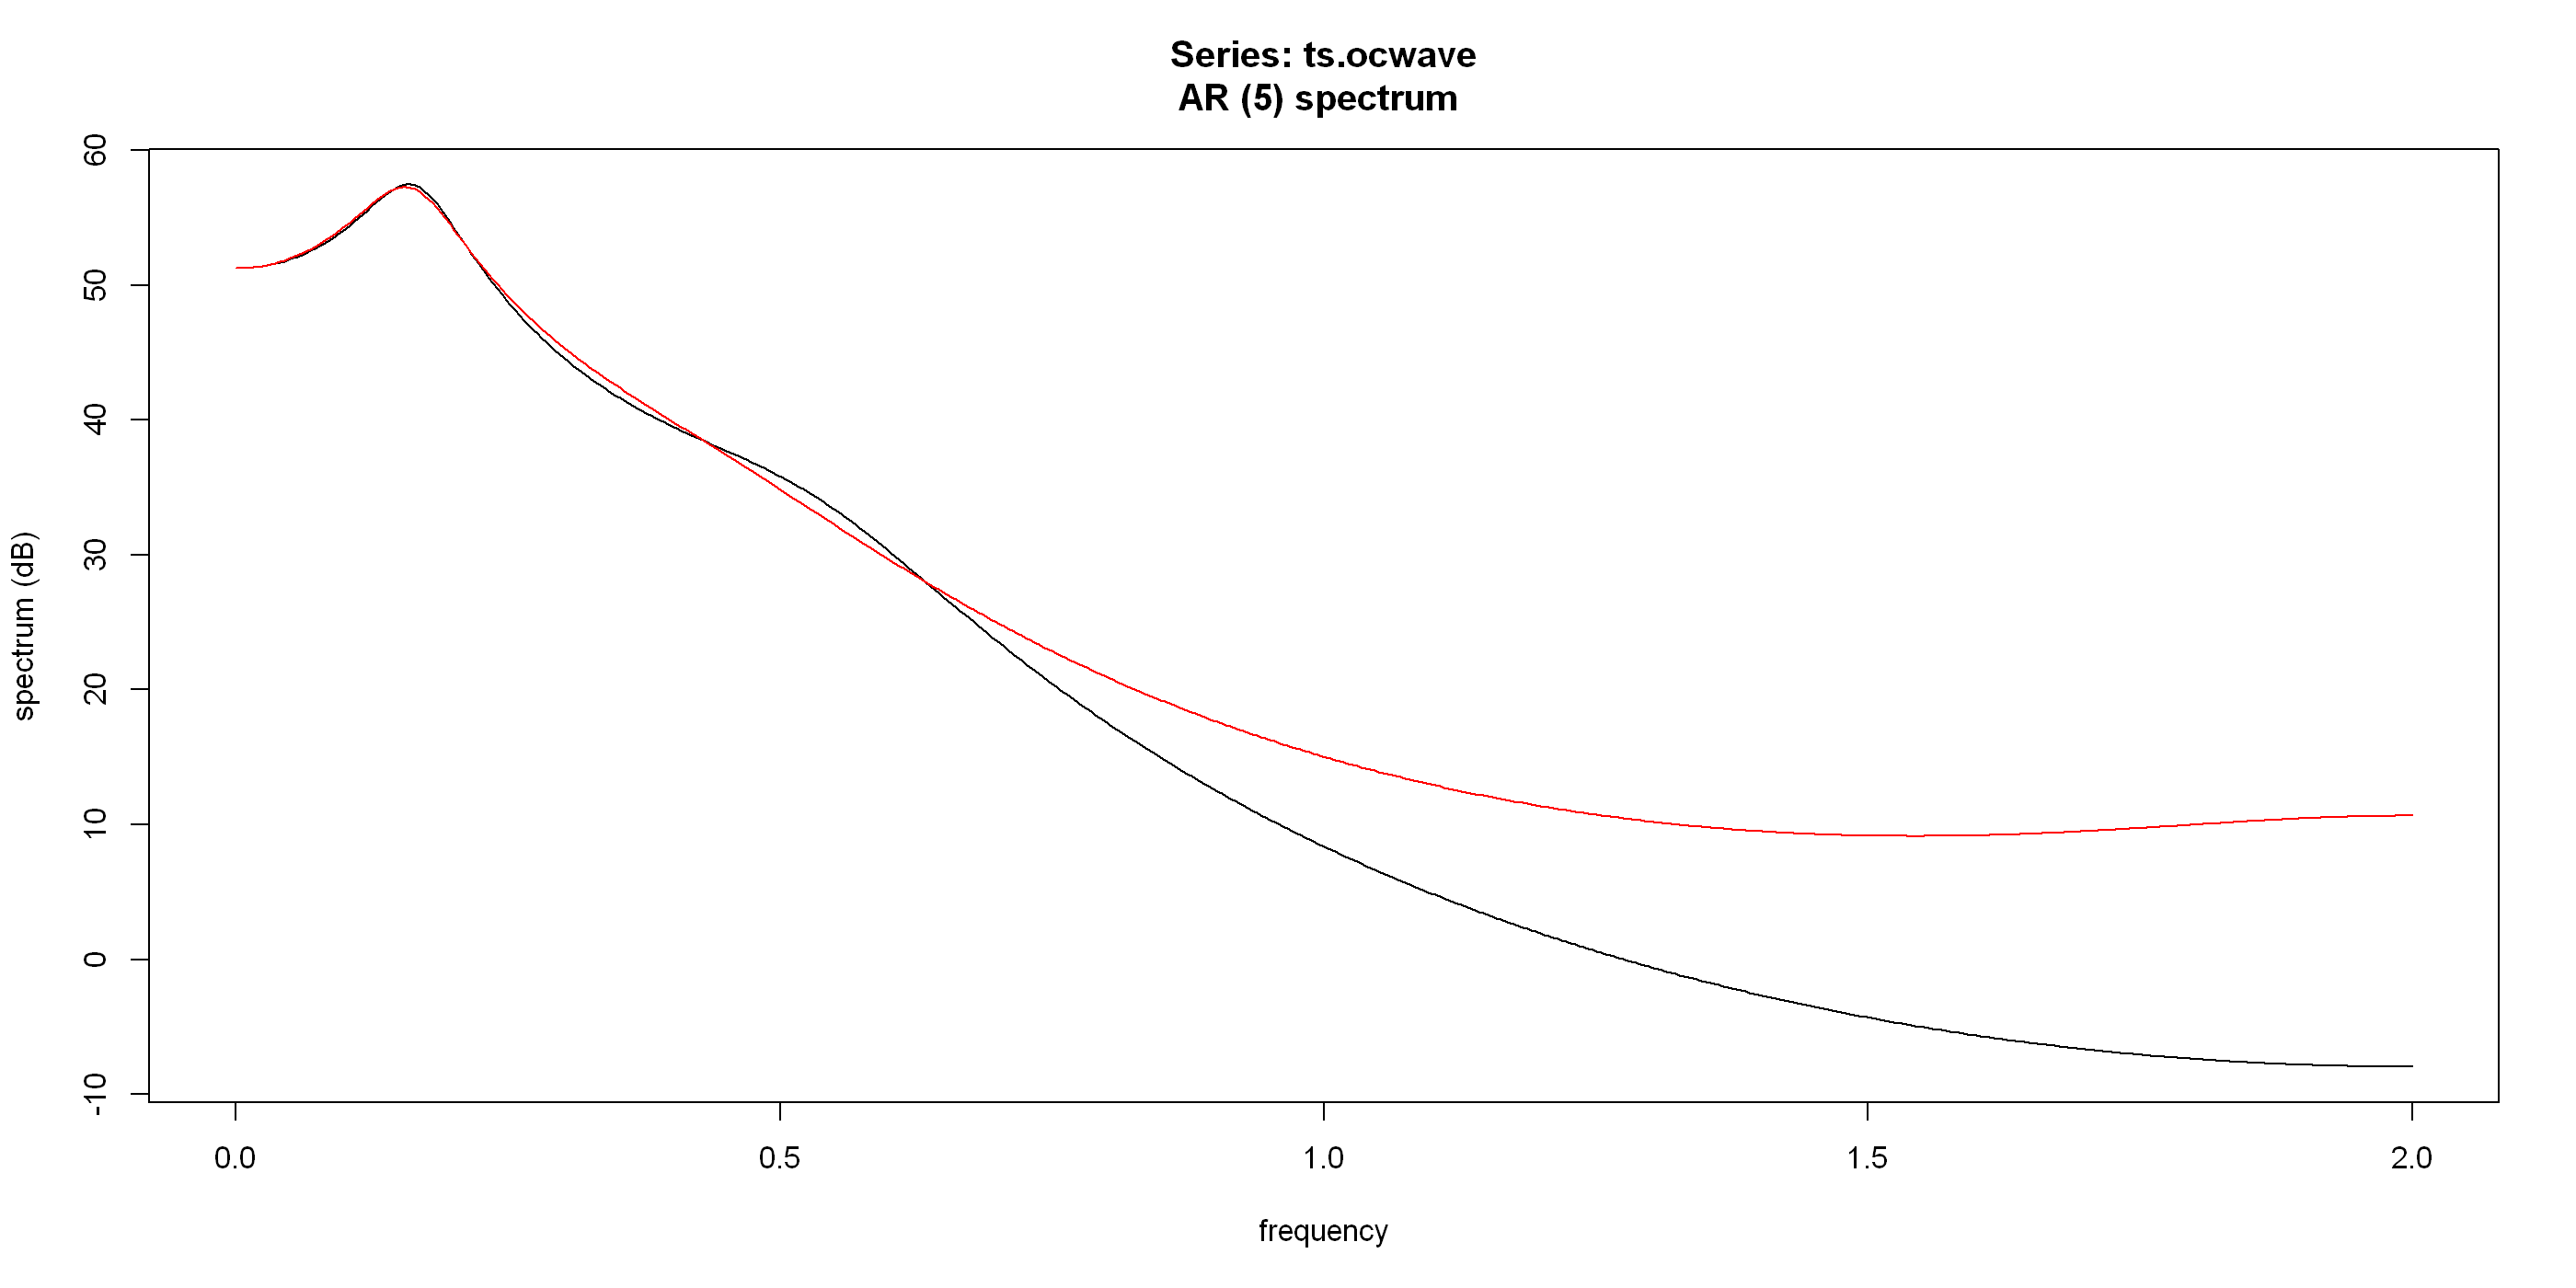

In [241]:
spec.ar(ocwave.burg, plot = TRUE, log = "dB")
spec.ar(ocwave.yw, add = TRUE,log="dB",col="red")